# Kokoro TTS — Streaming Vocos Export (ONNX + LiteRT)

## Overview

This notebook exports the Kokoro TTS pipeline, replacing the original **iSTFTNet** vocoder with
a causal **streaming Vocos** vocoder, to ONNX and LiteRT (TFLite) formats suitable for
on-device real-time inference.

The pipeline is split into six independently-exported modules plus one Python-only expansion step:

| Module | File | Shape regime | Description |
|--------|------|-------------|-------------|
| **BERT encoder** | `bert.{onnx,tflite}` | **Static** | Encodes phoneme IDs → text features `d_en` |
| **Duration predictor** | `duration_predictor.{onnx,tflite}` | **Static** | Predicts per-phoneme durations and returns pre-expansion features `d_enc`, `t_en_static` |
| *(Python)* | — | — | `expand_durations()`: computes `expanded_indices` from `pred_dur`, then `index_select` to expand `d_enc` and `t_en_static` |
| **Acoustic expand** | `acoustic_expand.{onnx,tflite}` | Dynamic T | Shared BiLSTM on expanded predictor features → `en` |
| **F0/N predictor** | `f0n_predictor.{onnx,tflite}` | Dynamic T | Predicts F0 (pitch) and noise curves from `en` |
| **Vocos conditioner** | `vocoder_conditioner.{onnx,tflite}` | Dynamic T | Full-sequence projection from `[asr, F0, N, style]` → conditioned features |
| **Vocos stream chunk** | `vocoder_stream_chunk.{onnx,tflite}` | **Static** | Causal ConvNeXt backbone + iSTFT head, one fixed-size chunk, explicit state I/O |

---

## Design Decisions

### Static vs dynamic shapes

| Stage | Static? | Reason |
|-------|---------|--------|
| BERT encoder | ✓ Static `[1, 510]` | Input padded to `MAX_INPUT_LENGTH=510` |
| Duration predictor | ✓ Static | Operates on padded 510-length tensors |
| Duration expansion | Python only | `torch.arange(T_acoustic)` requires dynamic size; not exported |
| Acoustic expand | Dynamic T | `T_acoustic` = sum of durations, varies per utterance |
| F0/N predictor | Dynamic T | Depends on `T_acoustic` |
| Vocos conditioner | Dynamic T | Depends on utterance length |
| Vocos stream chunk | ✓ Static `chunk_frames` | Fixed-size chunk; no dynamic axes needed |

### Vocoder replacement: iSTFTNet → streaming Vocos

The original Kokoro decoder uses **iSTFTNet**, which is non-causal and processes the entire
utterance at once.  A pre-trained **StreamingVocos** checkpoint (`vocos_fp16.pt`) replaces it.
Feature format fed to Vocos:

```
[B, 642, T_f0]  =  512 (asr)  +  1 (F0)  +  1 (N)  +  128 (style[:128])
```

### Conditioner / backbone split

The Vocos generator has two stages:
1. **Conditioner** — three `Conv1d` layers, the middle one has `kernel_size=3, padding=1`
   (non-causal). It *must* see the full sequence to avoid boundary artifacts.
2. **Backbone + head** — fully causal ConvNeXt stack + iSTFT; can be run chunk-by-chunk.

### Stateless streaming: explicit state passing

ONNX and LiteRT cannot represent stateful (hidden-variable) models.  Instead, the streaming
state is passed **explicitly** as inputs and returned as outputs on every chunk call.

**State tensors** (shapes for `chunk_frames=16`, `kernel_size=7`):

| Tensor | Shape | Role |
|--------|-------|------|
| `embed_prev` | `[1, 192, 6]` | Causal context for embed Conv1d (k−1 frames) |
| `block_{0..7}_prev` | `[1, 384, 6]` | Causal context for each ConvNeXt depthwise conv |
| `istft_prev` | `[1, 900]` | OLA overlap buffer (win_length − hop = 1200 − 300) |

### LiteRT: real-arithmetic ISTFT (`VocosStreamChunkReal`)

TFLite does not support complex-number tensors.  `VocosStreamChunk` uses `torch.fft.irfft`
which produces complex intermediates.  `VocosStreamChunkReal` replaces this with an explicit
real-arithmetic IDFT using precomputed cosine/sine basis matrices:

```
time[b, f, t] = Σ_k  cos_basis[k,t] * x_real[b,k,f]
              − Σ_k  sin_basis[k,t] * x_imag[b,k,f]
```

### Numerical precision

- All export modules use `float32`.
- ONNX max difference vs PyTorch should be `< 1e-5`.
- LiteRT difference may be slightly larger (`~1e-4`) due to TFLite op fusion.


In [1]:
%load_ext autoreload
%autoreload 2

import os
# os.environ["CUDA_VISIBLE_DEVICES"] = ""


In [2]:
# ── Standard library ──────────────────────────────────────────────────────────
import json
import os
import time
from pathlib import Path
from typing import Dict, Iterator, List, Mapping, Optional, Tuple

# ── Numerics / audio ──────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np
import scipy.io.wavfile as wavfile

# ── PyTorch ───────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor

# ── ONNX ─────────────────────────────────────────────────────────────────────
import onnx
import onnxruntime as ort

# ── Kokoro TTS ────────────────────────────────────────────────────────────────
from kokoro import KModel, KPipeline
from kokoro.model import KModelForONNX

# ── Streaming Vocos ───────────────────────────────────────────────────────────
from streaming_vocos import (
    StreamingVocos,
    StreamingVocosGenerator,
    _RawStreamingConv1d,
    _StreamingISTFT,
)

# ── Notebook display ──────────────────────────────────────────────────────────
from IPython.display import Audio, HTML, display

torch.set_num_threads(8)
print("Imports OK")

torch.set_printoptions(
    threshold=float('inf'),    # Show all elements (no truncation)
)


2026-03-17 22:52:24.037733: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-17 22:52:24.099653: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/rhome/eingerman/Projects/DeepLearning/TTS/Kokoro/.venv/lib/python3.12/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):
Skipping import of cpp extensions due to incompatible torch version 2.9.1+cu128 for torchao version 0.16.0             Please see 

Imports OK


In [3]:
# ── Model paths ───────────────────────────────────────────────────────────────
CONFIG_FILE      = "checkpoints/config.json"
CHECKPOINT_PATH  = "checkpoints/kokoro-v1_0.pth"
VOCOS_CKPT       = "vocos_fp16.pt"
VOICE_PATH       = "checkpoints/voices/af_bella.pt"

# ── Export directory ──────────────────────────────────────────────────────────
EXPORT_DIR = Path("onnx_streaming_vocos")
EXPORT_DIR.mkdir(exist_ok=True)

# ── Inference constants ────────────────────────────────────────────────────────
SAMPLE_RATE      = 24000
MAX_INPUT_LENGTH = 510
T_ACOUSTIC_MAX   = 8096
OPSET_VERSION    = 19

# ── Vocos streaming config ────────────────────────────────────────────────────
VOCOS_CHUNK_FRAMES  = 16           # frames per chunk through backbone+head
# hop_length read from checkpoint at load time (typically 300 for this model)

# ── Sample text ───────────────────────────────────────────────────────────────
TEXT = (
    "I had returned to civil practice and had finally abandoned Holmes in his "
    "Baker Street rooms, although I continually visited him and occasionally "
    "even persuaded him to forgo his Bohemian habits so far as to come and "
    "visit us."
)
print(f"{len(TEXT)=} characters in sample text")
print(f"Export dir : {EXPORT_DIR.resolve()}")
print(f"Chunk size : {VOCOS_CHUNK_FRAMES} frames")


len(TEXT)=224 characters in sample text
Export dir : /rhome/eingerman/Projects/DeepLearning/TTS/Kokoro/onnx_streaming_vocos
Chunk size : 16 frames


In [4]:
# Load Kokoro model
with open(CONFIG_FILE) as f:
    config = json.load(f)

kmodel = KModel(config=CONFIG_FILE, model=CHECKPOINT_PATH, disable_complex=True).to("cpu")
model  = KModelForONNX(kmodel).eval()
print("Kokoro model loaded")


/rhome/eingerman/Projects/DeepLearning/TTS/Kokoro/.venv/lib/python3.12/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Kokoro model loaded


In [5]:
# ── Input preparation helpers ─────────────────────────────────────────────────

def load_input_ids(pipeline: KPipeline, text: str):
    if pipeline.lang_code in "ab":
        _, tokens = pipeline.g2p(text)
        for gs, ps, tks in pipeline.en_tokenize(tokens):
            if not ps:
                continue
    else:
        ps, _ = pipeline.g2p(text)

    if len(ps) > 510:
        ps = ps[:510]

    input_ids = [i for i in (pipeline.model.vocab.get(p) for p in ps) if i is not None]
    input_ids = torch.LongTensor([[0, *input_ids, 0]]).to(pipeline.model.device)
    return ps, input_ids


def load_voice(pipeline: KPipeline, voice: str, phonemes):
    pack = pipeline.load_voice(voice).to("cpu")
    return pack[len(phonemes) - 1]


def load_sample(model: KModelForONNX, text: str = TEXT, voice: str = VOICE_PATH):
    pipeline = KPipeline(lang_code="a", model=model.kmodel, device="cpu")
    phonemes, input_ids = load_input_ids(pipeline, text)
    style = load_voice(pipeline, voice, phonemes)
    speed = torch.IntTensor([1])
    return input_ids, style, speed


def build_padded_inputs(input_ids: Tensor):
    """Pad input_ids to MAX_INPUT_LENGTH and build matching text_mask."""
    text_mask = torch.zeros(1, MAX_INPUT_LENGTH, dtype=torch.float32)
    text_mask[0, : input_ids.shape[1]] = 1
    input_ids = F.pad(input_ids, (0, MAX_INPUT_LENGTH - input_ids.shape[1]))
    return input_ids, text_mask


print("Helpers defined")


Helpers defined


In [6]:
# ═══════════════════════════════════════════════════════════════════════════════
#  Module definitions — BERT encoder, duration predictor, F0/N predictor,
#  Vocos conditioner, and stateless streaming Vocos chunk module
#
#  Static-shape modules (no dynamic axes in ONNX):
#    BertEncoderModule       — [1, 510] → [1, 512, 510]
#    DurationPredictorCore   — [1, 512, 510] + style/mask/speed/input_ids
#                               → pred_dur[510], d_enc[1,h,510], t_en[1,512,510]
#
#  Static-shape modules (T_acoustic padded to T_ACOUSTIC_MAX=8192):
#    AcousticExpandModule    — [1, h, T_ACOUSTIC_MAX] → [1, T_ACOUSTIC_MAX, h_shared]
#    F0NPredictorModule      — [1, T_ACOUSTIC_MAX, h_shared] → F0[1,2*T_MAX], N[1,2*T_MAX]  (F0Ntrain 2× upsample)
#    VocosConditionerModule  — [1, 642, 2*T_MAX] → [1, C, 2*T_MAX]
#
#  Static-shape chunk module:
#    VocosStreamChunk        — [1, C, chunk_frames] + state → audio + state
# ═══════════════════════════════════════════════════════════════════════════════


# ── 1. BERT encoder  (STATIC: input [1, 510] → output [1, 512, 510]) ──────────
class BertEncoderModule(nn.Module):
    """input_ids [1,510] → d_en [1,512,510]  — static shapes, no dynamic axes."""
    def __init__(self, kmodel):
        super().__init__()
        self.bert         = kmodel.bert
        self.bert_encoder = kmodel.bert_encoder

    def forward(self, input_ids: Tensor, text_mask: Tensor) -> Tensor:
        bert_dur = self.bert(input_ids, attention_mask=text_mask)
        return self.bert_encoder(bert_dur).transpose(-1, -2)


# ── 2. Duration predictor core  (STATIC: all I/O have shape determined by 510) ─
class DurationPredictorCore(nn.Module):
    """Predict per-phoneme durations and produce pre-expansion feature tensors.

    All shapes are static (padded to MAX_INPUT_LENGTH=510):
        Inputs:
            d_en       [1, 512, 510]   — BERT encoder output
            style      [1, 256]        — voice style vector
            text_mask  [1, 510]        — valid-token mask (float)
            speed      []  int32       — speed multiplier
            input_ids  [1, 510]        — token IDs for text_encoder

        Outputs:
            pred_dur   [510]           — rounded per-phoneme durations
                                         (0 at padding positions, masked by text_mask)
            d_enc      [1, h, 510]     — predictor text-encoder features (C-first)
            t_en       [1, 512, 510]   — text-encoder features for ASR path
    """
    def __init__(self, kmodel):
        super().__init__()
        self.predictor    = kmodel.predictor
        self.text_encoder = kmodel.text_encoder

    def forward(
        self,
        d_en: Tensor,
        style: Tensor,
        text_mask: Tensor,
        speed: Tensor,
        input_ids: Tensor,
    ):
        d = self.predictor.text_encoder(d_en, style[:, 128:], text_mask)
        x, _ = self.predictor.lstm(d)
        duration = self.predictor.duration_proj(x)
        duration = text_mask * torch.sigmoid(duration).sum(axis=-1) / speed.float()
        pred_dur = torch.round(duration).squeeze()          # [510] — static

        d_enc = d.transpose(-1, -2)                         # [1, h, 510] — static
        t_en  = self.text_encoder(input_ids, text_mask)     # [1, 512, 510] — static

        return pred_dur, d_enc, t_en


# ── 3. Duration expansion helper  (Python, not exported) ─────────────────────
def expand_durations(pred_dur: Tensor, T_max: int = T_ACOUSTIC_MAX) -> Tuple[Tensor, int]:
    """Compute expanded indices padded to T_max from rounded per-phoneme durations.

    This runs in Python between DurationPredictorCore and AcousticExpandModule.
    It is intentionally NOT exported. The fixed output size T_max enables
    fully static shapes in all downstream ONNX modules.

    Args:
        pred_dur: [510] float — rounded durations (0 for padding positions)
        T_max:    fixed output length (default: T_ACOUSTIC_MAX)

    Returns:
        expanded_indices: [T_max] long — index into the 510-length phoneme dim;
                          frames beyond the actual duration clamp to the last
                          valid phoneme index.
        T_acoustic:       int — actual number of valid frames (<= T_max)
    """
    boundaries = torch.cumsum(pred_dur, dim=0)
    T_acoustic = min(int(boundaries[-1].item()), T_max)
    # boundaries[-1] = T_max
    values = torch.arange(boundaries[-1])
    expanded_indices = torch.sum(
        boundaries.unsqueeze(1) <= values.unsqueeze(0), dim=0
    ).long()
    # print(f"Expanded to {T_acoustic} frames (clamped to {T_max}):")
    # print(f"{pred_dur.shape=} {pred_dur=}")
    # print(f"{boundaries.shape=} {boundaries=}")
    # print(f"{expanded_indices.shape=} {expanded_indices=}")
    return expanded_indices, T_acoustic


# ── 4. Acoustic expand module  (STATIC T_ACOUSTIC_MAX) ─────────────────────
class AcousticExpandModule(nn.Module):
    """Apply shared BiLSTM to already-expanded predictor features.

    The caller must perform the index_select expansion in Python (using
    expand_durations) before calling this module.

        Input:  d_enc_expanded  [1, h, T_ACOUSTIC_MAX]  — C-first, static T
        Output: en              [1, T_ACOUSTIC_MAX, h']  — after shared BiLSTM
    """
    def __init__(self, kmodel):
        super().__init__()
        self.shared = kmodel.predictor.shared

    def forward(self, d_enc_expanded: Tensor) -> Tensor:
        en, _ = self.shared(d_enc_expanded.transpose(-1, -2))
        return en


# ── 5. F0 & noise predictor  (STATIC T_ACOUSTIC_MAX) ───────────────────────────
class F0NPredictorModule(nn.Module):
    """(en [1,T_ACOUSTIC_MAX,h'], style) → (F0_pred [1,2*T_ACOUSTIC_MAX], N_pred [1,2*T_ACOUSTIC_MAX])  — F0Ntrain 2× upsample"""
    def __init__(self, kmodel):
        super().__init__()
        self.predictor = kmodel.predictor

    def forward(self, en: Tensor, style: Tensor):
        return self.predictor.F0Ntrain(en, style[:, 128:256])


# ── 6. Vocos conditioner (full-sequence, non-causal, static T_ACOUSTIC_MAX) ────
class VocosConditionerModule(nn.Module):
    """features [1,642,2*T_ACOUSTIC_MAX] → conditioned [1,model_input_channels,2*T_ACOUSTIC_MAX]"""
    def __init__(self, vocos: StreamingVocos):
        super().__init__()
        self.conditioner = vocos.model.conditioner

    def forward(self, features: Tensor) -> Tensor:
        return self.conditioner(features)


# ── 7. Feature builder helper ─────────────────────────────────────────────────
def build_vocos_features(
    asr: Tensor,         # [1, 512, T_asr]
    F0_pred: Tensor,     # [1, T_f0]
    N_pred: Tensor,      # [1, T_f0]
    style: Tensor,       # [1, 256]
) -> Tensor:
    """Assemble [1, 642, T_f0] feature tensor matching vocos training format."""
    B, _, T_asr = asr.shape
    T_f0 = F0_pred.shape[-1]
    if T_asr != T_f0:
        asr = F.interpolate(asr.float(), size=T_f0, mode="linear", align_corners=False)
    f0    = F0_pred.unsqueeze(1).float()
    n     = N_pred.unsqueeze(1).float()
    s_exp = style[:, :128].unsqueeze(-1).expand(B, -1, T_f0)
    return torch.cat([asr, f0, n, s_exp], dim=1)   # [1, 642, T_f0]


# ── 8. Streaming Vocos chunk module  (STATIC chunk_frames) ───────────────────
class VocosStreamChunk(nn.Module):
    """Stateless single-chunk backbone+head for ONNX/LiteRT export.

    The conditioner must be applied externally to the full sequence before
    calling this module chunk-by-chunk.

    State layout (9 'previous' + 1 ISTFT buffer):
        embed_prev      : [1, 192, 6]
        block_0_prev    : [1, 384, 6]
        ...
        block_7_prev    : [1, 384, 6]
        istft_prev      : [1, 900]

    All state tensors are returned in the same order they are accepted,
    after the audio output.  Initialise with zeros via :meth:`initial_state`.
    """

    EMBED_IN   = 192    # embed conv in-channels
    BLOCK_DIM  = 384    # backbone dim (depthwise conv in/out channels)
    KERNEL_M1  = 6      # k=7 → k-1 = 6 context frames per causal conv
    ISTFT_TAIL = 900    # win_length - hop = 1200 - 300
    N_LAYERS   = 8

    def __init__(self, vocos: StreamingVocos):
        super().__init__()
        bb = vocos.model.backbone
        hd = vocos.model.head

        self.embed_norm_conv = bb.embed.conv            # _NormConv1d, padding=0
        self.backbone_norm   = bb.norm                  # LayerNorm (over C)
        self.convnext        = bb.convnext              # ModuleList
        self.final_ln        = bb.final_layer_norm

        self.head_out        = hd.out                   # nn.Linear
        self.overlap_add     = hd.istft.overlap_add.deconv  # ConvTranspose1d OLA
        self.register_buffer("window", hd.istft.window)
        self.n_fft    = hd.istft.n_fft
        self.hop      = hd.istft.hop
        self.win_len  = hd.istft.win_length
        self.tail     = hd.istft.tail

    # ── Helpers ───────────────────────────────────────────────────────────────
    @staticmethod
    def initial_state() -> Dict[str, Tensor]:
        """Return zero-initialised streaming state for the first chunk."""
        state: Dict[str, Tensor] = {
            "embed_prev": torch.zeros(1, VocosStreamChunk.EMBED_IN, VocosStreamChunk.KERNEL_M1),
            "istft_prev": torch.zeros(1, VocosStreamChunk.ISTFT_TAIL),
        }
        for i in range(VocosStreamChunk.N_LAYERS):
            state[f"block_{i}_prev"] = torch.zeros(1, VocosStreamChunk.BLOCK_DIM, VocosStreamChunk.KERNEL_M1)
        return state

    def state_as_tuple(self, state: Dict[str, Tensor]) -> Tuple[Tensor, ...]:
        """Convert state dict to the ordered tuple used by forward()."""
        keys = ["embed_prev"] + [f"block_{i}_prev" for i in range(self.N_LAYERS)] + ["istft_prev"]
        return tuple(state[k] for k in keys)

    def state_from_tuple(self, t: Tuple[Tensor, ...]) -> Dict[str, Tensor]:
        """Convert forward() output tuple (after audio) back to state dict."""
        keys = ["embed_prev"] + [f"block_{i}_prev" for i in range(self.N_LAYERS)] + ["istft_prev"]
        return dict(zip(keys, t))

    def _causal_conv(
        self,
        norm_conv1d: nn.Module,
        x: Tensor,
        prev: Tensor,
    ) -> Tuple[Tensor, Tensor]:
        """Apply k=7 causal conv: cat context, run NormConv1d (no pad), return output + new context."""
        xp = torch.cat([prev, x], dim=-1)   # [1, C_in, k-1+T]
        y  = norm_conv1d(xp)                # [1, C_out, T]
        return y, xp[..., -self.KERNEL_M1:]  # new_prev = last k-1 frames

    # ── Forward ───────────────────────────────────────────────────────────────
    def forward(
        self,
        conditioned_chunk: Tensor,   # [1, model_input_channels, chunk_frames]
        embed_prev: Tensor,          # [1, EMBED_IN, 6]
        *block_and_istft,            # block_0_prev, ..., block_7_prev, istft_prev
    ) -> Tuple[Tensor, ...]:
        """
        Returns: (audio [1, chunk_frames*hop], embed_prev_new,
                  block_0_prev_new, ..., block_7_prev_new, istft_prev_new)
        """
        block_prevs = list(block_and_istft[:self.N_LAYERS])
        istft_prev  = block_and_istft[self.N_LAYERS]

        # ── Backbone: embed ───────────────────────────────────────────────────
        x, new_embed_prev = self._causal_conv(self.embed_norm_conv, conditioned_chunk, embed_prev)
        x = self.backbone_norm(x.transpose(1, 2)).transpose(1, 2)

        # ── Backbone: ConvNeXt blocks ─────────────────────────────────────────
        new_block_prevs: List[Tensor] = []
        for i, block in enumerate(self.convnext):
            identity = x
            xd, new_bp = self._causal_conv(block.dwconv.conv, x, block_prevs[i])
            new_block_prevs.append(new_bp)
            xd = xd.permute(0, 2, 1)       # [1, T, C]
            xd = block.norm(xd)
            xd = block.pwconv1(xd)
            xd = block.act(xd)
            xd = block.pwconv2(xd)
            xd = block.gamma * xd
            xd = xd.permute(0, 2, 1)       # [1, C, T]
            x  = identity + xd

        x = self.final_ln(x.transpose(1, 2)).transpose(1, 2)

        # ── Head: linear projection → complex STFT spectrum ───────────────────
        frames = x.shape[-1]
        h    = self.head_out(x.transpose(1, 2)).transpose(1, 2)  # [1, n_fft+2, frames]
        mag, phase = h.chunk(2, dim=1)
        mag  = torch.exp(mag).clamp(max=1e2)
        spec = mag * (torch.cos(phase) + 1j * torch.sin(phase))  # [1, n_fft//2+1, frames]

        # ── Head: streaming ISTFT with explicit OLA state ─────────────────────
        time_frames = torch.fft.irfft(spec.transpose(1, 2), n=self.n_fft)[..., : self.win_len]
        time_frames = time_frames * self.window                  # apply Hann window
        ola_in  = time_frames.transpose(1, 2)                    # [1, win_len, frames]
        ola_out = self.overlap_add(ola_in)[:, 0, :]               # [1, frames*hop + tail]

        audio_overlap  = ola_out[:, :self.tail] + istft_prev     # [1, tail]
        audio_rest     = ola_out[:, self.tail : frames * self.hop]
        audio          = torch.cat([audio_overlap, audio_rest], dim=-1)  # [1, frames*hop]
        new_istft_prev = ola_out[:, frames * self.hop:]           # [1, tail]

        return (audio, new_embed_prev) + tuple(new_block_prevs) + (new_istft_prev,)


# ── Convenience: run full vocos synthesis through the streaming chunk module ─
def vocos_forward_full(
    stream_chunk: VocosStreamChunk,
    conditioned: Tensor,             # [1, model_input_channels, T_total]
    chunk_frames: int = VOCOS_CHUNK_FRAMES,
) -> Tensor:
    """Run all chunks through VocosStreamChunk; return concatenated audio."""
    state = stream_chunk.state_as_tuple(VocosStreamChunk.initial_state())
    chunks: List[Tensor] = []
    total = conditioned.shape[-1]
    pos   = 0
    while pos < total:
        end  = min(total, pos + chunk_frames)
        chunk = conditioned[..., pos:end]
        valid = int(end - pos)
        if valid < chunk_frames:
            chunk = F.pad(chunk, (0, chunk_frames - valid))
        out   = stream_chunk(chunk, *state)
        audio_chunk = out[0]
        state = out[1:]
        chunks.append(audio_chunk[..., : valid * stream_chunk.hop])
        pos = end
    return torch.cat(chunks, dim=-1).squeeze(0)


# ── 9. LiteRT-compatible variant: replaces complex irfft with real matmul ─────
import math as _math

class VocosStreamChunkReal(VocosStreamChunk):
    """LiteRT / TFLite-compatible variant.

    Replaces the complex-valued irfft with an explicit real-arithmetic IDFT
    using precomputed cosine/sine basis matrices, avoiding any use of
    complex tensors.  All other logic is identical to VocosStreamChunk.
    """

    def __init__(self, vocos: StreamingVocos):
        super().__init__(vocos)
        K = self.n_fft // 2 + 1
        k = torch.arange(K).float()
        t = torch.arange(self.n_fft).float()
        angle = 2 * _math.pi * k.unsqueeze(1) * t.unsqueeze(0) / self.n_fft
        weights = torch.ones(K)
        weights[1:-1] = 2.0   # DC and Nyquist have weight 1, rest 2 (Hermitian symmetry)
        self.register_buffer("cos_basis", (weights.unsqueeze(1) * torch.cos(angle)) / self.n_fft)
        self.register_buffer("sin_basis", (weights.unsqueeze(1) * torch.sin(angle)) / self.n_fft)

    def forward(
        self,
        conditioned_chunk: Tensor,
        embed_prev: Tensor,
        *block_and_istft,
    ) -> Tuple[Tensor, ...]:
        block_prevs = list(block_and_istft[:self.N_LAYERS])
        istft_prev  = block_and_istft[self.N_LAYERS]

        # ── Backbone (identical to parent) ────────────────────────────────────
        x, new_embed_prev = self._causal_conv(self.embed_norm_conv, conditioned_chunk, embed_prev)
        x = self.backbone_norm(x.transpose(1, 2)).transpose(1, 2)

        new_block_prevs: List[Tensor] = []
        for i, block in enumerate(self.convnext):
            identity = x
            xd, new_bp = self._causal_conv(block.dwconv.conv, x, block_prevs[i])
            new_block_prevs.append(new_bp)
            xd = xd.permute(0, 2, 1)
            xd = block.norm(xd)
            xd = block.pwconv1(xd)
            xd = block.act(xd)
            xd = block.pwconv2(xd)
            xd = block.gamma * xd
            xd = xd.permute(0, 2, 1)
            x  = identity + xd

        x = self.final_ln(x.transpose(1, 2)).transpose(1, 2)

        # ── Head: linear projection ───────────────────────────────────────────
        frames = x.shape[-1]
        h      = self.head_out(x.transpose(1, 2)).transpose(1, 2)   # [1, n_fft+2, frames]
        mag, phase = h.chunk(2, dim=1)
        mag    = torch.exp(mag).clamp(max=1e2)
        x_real = mag * torch.cos(phase)   # [1, K, frames]
        x_imag = mag * torch.sin(phase)   # [1, K, frames]

        time_frames = (
            torch.einsum("kt,bkf->bft", self.cos_basis, x_real)
            - torch.einsum("kt,bkf->bft", self.sin_basis, x_imag)
        )[..., : self.win_len]           # [1, frames, win_len]
        time_frames = time_frames * self.window

        # ── Streaming ISTFT overlap-add (identical to parent) ─────────────────
        ola_in  = time_frames.transpose(1, 2)                        # [1, win_len, frames]
        ola_out = self.overlap_add(ola_in)[:, 0, :]                   # [1, frames*hop + tail]

        audio_overlap  = ola_out[:, :self.tail] + istft_prev
        audio_rest     = ola_out[:, self.tail : frames * self.hop]
        audio          = torch.cat([audio_overlap, audio_rest], dim=-1)
        new_istft_prev = ola_out[:, frames * self.hop:]

        return (audio, new_embed_prev) + tuple(new_block_prevs) + (new_istft_prev,)


print("All modules defined:")
print("  BertEncoderModule        — BERT + encoder projection        [STATIC]")
print("  DurationPredictorCore    — duration prediction, no expansion [STATIC]")
print("  expand_durations()       — Python helper: pred_dur → expanded_indices")
print("  AcousticExpandModule     — shared BiLSTM on expanded features [STATIC T_ACOUSTIC_MAX]")
print("  F0NPredictorModule       — F0 & noise prediction             [STATIC T_ACOUSTIC_MAX]")
print("  VocosConditionerModule   — full-seq vocos conditioner        [STATIC T_ACOUSTIC_MAX]")
print("  VocosStreamChunk         — causal backbone+head, explicit state I/O (complex ISTFT) [STATIC chunk]")
print("  VocosStreamChunkReal     — same, real-arithmetic ISTFT for LiteRT/TFLite [STATIC chunk]")


All modules defined:
  BertEncoderModule        — BERT + encoder projection        [STATIC]
  DurationPredictorCore    — duration prediction, no expansion [STATIC]
  expand_durations()       — Python helper: pred_dur → expanded_indices
  AcousticExpandModule     — shared BiLSTM on expanded features [STATIC T_ACOUSTIC_MAX]
  F0NPredictorModule       — F0 & noise prediction             [STATIC T_ACOUSTIC_MAX]
  VocosConditionerModule   — full-seq vocos conditioner        [STATIC T_ACOUSTIC_MAX]
  VocosStreamChunk         — causal backbone+head, explicit state I/O (complex ISTFT) [STATIC chunk]
  VocosStreamChunkReal     — same, real-arithmetic ISTFT for LiteRT/TFLite [STATIC chunk]


In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
#  PyTorch inference  — iSTFTNet reference + Vocos one-shot + Vocos streaming
# ═══════════════════════════════════════════════════════════════════════════════

# ── Timing helpers ─────────────────────────────────────────────────────────────
def _t() -> float:
    """High-resolution wall-clock timestamp in seconds."""
    return time.perf_counter()


def print_timing_table(timings: dict, title: str = "Pipeline Timing"):
    """Print a formatted table of stage timings and percentages."""
    total = sum(timings.values())
    col_w = max(len(s) for s in timings) + 2
    print(f"\n{'─' * (col_w + 26)}")
    print(f"  {title}")
    print(f"{'─' * (col_w + 26)}")
    print(f"  {'Stage':<{col_w}} {'ms':>8}  {'%':>6}")
    print(f"  {'─' * (col_w + 18)}")
    for stage, ms in timings.items():
        print(f"  {stage:<{col_w}} {ms:>8.1f}  {ms / total * 100:>5.1f}%")
    print(f"  {'─' * (col_w + 18)}")
    print(f"  {'TOTAL':<{col_w}} {total:>8.1f}  {'100.0%':>6}")
    print(f"{'─' * (col_w + 26)}\n")


# ── Load vocos model (once) ────────────────────────────────────────────────────
vocos = StreamingVocos.from_checkpoint(VOCOS_CKPT, chunk_frames=VOCOS_CHUNK_FRAMES, device="cpu", use_fp16=False)

# ── Instantiate export modules (shared weights — no parameter copies) ──────────
bert_module      = BertEncoderModule(model.kmodel).eval()
duration_module  = DurationPredictorCore(model.kmodel).eval()
acoustic_module  = AcousticExpandModule(model.kmodel).eval()
f0n_module       = F0NPredictorModule(model.kmodel).eval()
cond_module      = VocosConditionerModule(vocos).eval()
stream_chunk     = VocosStreamChunk(vocos).eval()

# ── Prepare inputs ─────────────────────────────────────────────────────────────
raw_input_ids, style, speed = load_sample(model, text=TEXT, voice=VOICE_PATH)
input_ids, text_mask = build_padded_inputs(raw_input_ids)
print(f"input_ids shape   : {input_ids.shape}   (static, padded to {MAX_INPUT_LENGTH})")
print(f"text_mask shape   : {text_mask.shape}")

pt_timings: dict = {}

with torch.no_grad():
    # ── Stage 1: BERT encoder ──────────────────────────────────────────────────
    t0 = _t()
    d_en = bert_module(input_ids, text_mask)
    pt_timings["bert_encoder"] = (_t() - t0) * 1e3

    # ── Stage 2: Duration predictor (static) ──────────────────────────────────
    t0 = _t()
    pred_dur, d_enc, t_en_static = duration_module(d_en, style, text_mask, speed, input_ids)
    pt_timings["duration_predictor"] = (_t() - t0) * 1e3

    # ── Stage 3: Duration expansion (Python, not exported) ────────────────────
    t0 = _t()
    expanded_indices, T_acoustic = expand_durations(pred_dur)  # indices [T_ACOUSTIC_MAX], actual len
    d_enc_exp = torch.index_select(d_enc, 2, expanded_indices)      # [1, h, T_ACOUSTIC_MAX]
    asr_full  = torch.index_select(t_en_static, 2, expanded_indices)  # [1, 512, T_ACOUSTIC_MAX]
    pt_timings["duration_expansion_py"] = (_t() - t0) * 1e3

    # ── Stage 4: Acoustic expand (shared BiLSTM) ──────────────────────────────
    t0 = _t()
    en = acoustic_module(d_enc_exp)   # [1, T_ACOUSTIC_MAX, h_shared]
    pt_timings["acoustic_expand_lstm"] = (_t() - t0) * 1e3

    # ── Stage 5: F0 / noise prediction ────────────────────────────────────────
    t0 = _t()
    F0_pred_full, N_pred_full = f0n_module(en, style)  # [1, 2*T_ACOUSTIC_MAX] each (F0Ntrain 2× upsample)
    pt_timings["f0n_predictor"] = (_t() - t0) * 1e3

    # ── Trim outputs back to actual acoustic length ────────────────────────────
    # asr/d_enc live at T_acoustic; F0/N are 2× upsampled by F0Ntrain,
    # then decoder's stride-2 F0_conv folds them back down to T_acoustic.
    asr     = asr_full[..., :T_acoustic]            # [1, 512, T_acoustic]
    F0_pred = F0_pred_full[..., :2 * T_acoustic]    # [1, 2*T_acoustic]
    N_pred  = N_pred_full[..., :2 * T_acoustic]     # [1, 2*T_acoustic]

    # ── Stage 6: Reference iSTFTNet decoder ───────────────────────────────────
    t0 = _t()
    audio_ref = model.kmodel.decoder(asr, F0_pred, N_pred, style[:, 0:128]).squeeze().cpu()
    pt_timings["istftnet_decoder_ref"] = (_t() - t0) * 1e3

    # ── Stage 7: Vocos conditioner (trimmed inputs → no extra trim needed) ─────
    t0 = _t()
    features    = build_vocos_features(asr, F0_pred, N_pred, style)  # [1, 642, 2*T_acoustic]
    conditioned = cond_module(features.float())                       # [1, C, 2*T_acoustic]
    pt_timings["vocos_conditioner"] = (_t() - t0) * 1e3

    # ── Stage 8: Vocos streaming chunks ───────────────────────────────────────
    state       = stream_chunk.state_as_tuple(VocosStreamChunk.initial_state())
    chunks: List[Tensor] = []
    total_t     = conditioned.shape[-1]
    pos         = 0
    n_chunks    = 0
    t_vocos_chunks = 0.0
    while pos < total_t:
        end   = min(total_t, pos + VOCOS_CHUNK_FRAMES)
        chunk = conditioned[..., pos:end]
        valid = int(end - pos)
        if valid < VOCOS_CHUNK_FRAMES:
            chunk = F.pad(chunk, (0, VOCOS_CHUNK_FRAMES - valid))
        t0 = _t()
        out = stream_chunk(chunk, *state)
        t_vocos_chunks += (_t() - t0) * 1e3
        state = out[1:]
        chunks.append(out[0][..., : valid * stream_chunk.hop])
        pos = end
        n_chunks += 1
    audio_vocos = torch.cat(chunks, dim=-1).squeeze(0)
    pt_timings[f"vocos_chunks (×{n_chunks})"] = t_vocos_chunks

    # Reference one-shot check
    audio_vocos_oneshot = vocos.model(features.float())
    if audio_vocos_oneshot.ndim == 2 and audio_vocos_oneshot.shape[0] == 1:
        audio_vocos_oneshot = audio_vocos_oneshot.squeeze(0)

# ── Save wavs ──────────────────────────────────────────────────────────────────
pt_wav_path    = EXPORT_DIR / "pt_istftnet.wav"
vocos_wav_path = EXPORT_DIR / "pt_vocos_streaming.wav"
wavfile.write(str(pt_wav_path),    SAMPLE_RATE, (audio_ref.numpy()         * 32767).astype("int16"))
wavfile.write(str(vocos_wav_path), SAMPLE_RATE, (audio_vocos.cpu().numpy() * 32767).astype("int16"))
print(f"Saved {pt_wav_path}")
print(f"Saved {vocos_wav_path}")

diff_chunk_vs_oneshot = (audio_vocos.cpu() - audio_vocos_oneshot.cpu()).abs().max().item()
print(f"\niSTFTNet shape : {audio_ref.shape}")
print(f"Vocos shape    : {audio_vocos.shape}")
print(f"T_acoustic     : {T_acoustic}  frames  (padded to T_ACOUSTIC_MAX={T_ACOUSTIC_MAX}, {n_chunks} chunks of {VOCOS_CHUNK_FRAMES})")
print(f"Chunk vs one-shot max diff : {diff_chunk_vs_oneshot:.6f}  (should be ≈0)")

print_timing_table(pt_timings, title="PyTorch Pipeline Timing")


input_ids shape   : torch.Size([1, 510])   (static, padded to 510)
text_mask shape   : torch.Size([1, 510])
Saved onnx_streaming_vocos/pt_istftnet.wav
Saved onnx_streaming_vocos/pt_vocos_streaming.wav

iSTFTNet shape : torch.Size([325800])
Vocos shape    : torch.Size([325800])
T_acoustic     : 543  frames  (padded to T_ACOUSTIC_MAX=8096, 68 chunks of 16)
Chunk vs one-shot max diff : 0.000124  (should be ≈0)

─────────────────────────────────────────────────
  PyTorch Pipeline Timing
─────────────────────────────────────────────────
  Stage                         ms       %
  ─────────────────────────────────────────
  bert_encoder               222.1    7.5%
  duration_predictor          63.2    2.1%
  duration_expansion_py        0.6    0.0%
  acoustic_expand_lstm        10.1    0.3%
  f0n_predictor               26.8    0.9%
  istftnet_decoder_ref      2191.7   73.9%
  vocos_conditioner            5.5    0.2%
  vocos_chunks (×68)         445.6   15.0%
  ─────────────────────────────

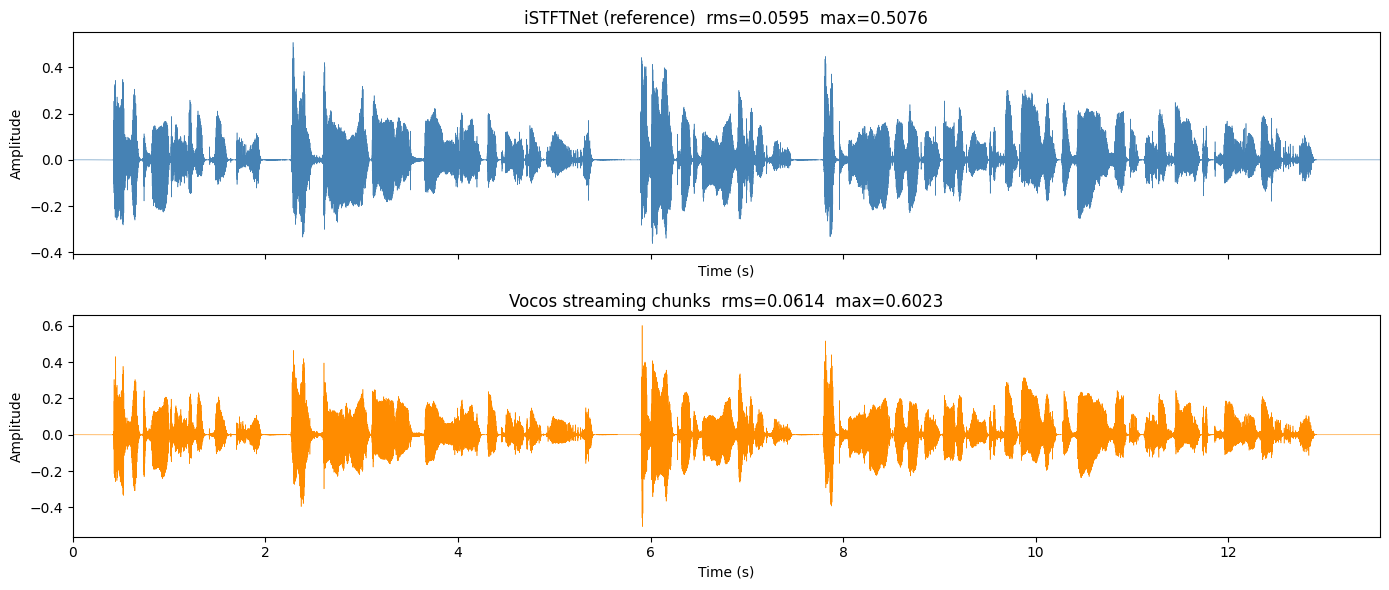

In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
#  Waveform comparison: iSTFTNet reference vs Vocos
# ═══════════════════════════════════════════════════════════════════════════════

def plot_wave(ax, wav, title, color="steelblue"):
    t = torch.arange(len(wav)).float() / SAMPLE_RATE
    ax.plot(t.numpy(), wav.detach().float().numpy(), linewidth=0.4, color=color)
    rms = float(wav.float().pow(2).mean().sqrt())
    ax.set_title(f"{title}  rms={rms:.4f}  max={float(wav.abs().max()):.4f}")
    ax.set_ylabel("Amplitude")
    ax.set_xlim(0, t[-1].item())
    ax.set_xlabel("Time (s)")

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
plot_wave(axes[0], audio_ref,   "iSTFTNet (reference)",  "steelblue")
plot_wave(axes[1], audio_vocos, "Vocos streaming chunks", "darkorange")
plt.tight_layout()
plt.savefig(str(EXPORT_DIR / "waveform_comparison.png"), dpi=100)
plt.show()

display(HTML("<b>Reference — iSTFTNet:</b>"))
display(Audio(audio_ref.cpu().numpy(), rate=SAMPLE_RATE))

display(HTML("<b>Vocos — streaming chunks (conditioner full-seq):</b>"))
display(Audio(audio_vocos.cpu().numpy(), rate=SAMPLE_RATE))


In [9]:
# ═══════════════════════════════════════════════════════════════════════════════
#  ONNX Export
# ═══════════════════════════════════════════════════════════════════════════════
#
#  Static-shape exports (no dynamic_axes):
#    bert.onnx                — BERT encoder         [1,510] → [1,512,510]
#    duration_predictor.onnx  — DurationPredictorCore [static 510-length I/O]
#
#  Static-shape exports (T_acoustic fixed at T_ACOUSTIC_MAX=8192):
#    acoustic_expand.onnx     — AcousticExpandModule  [1,h,T_max] → [1,T_max,h']
#    f0n_predictor.onnx       — F0 + noise predictor  [1,T_max,h'] → F0[1,T_max], N[1,T_max]
#    vocoder_conditioner.onnx — Vocos conditioner      [1,642,T_max] → [1,C,T_max]
#    vocoder_stream_chunk.onnx— Vocos backbone+head    [static chunk] + state
#
# ═══════════════════════════════════════════════════════════════════════════════

onnx_paths: Dict[str, Path] = {
    "bert":           EXPORT_DIR / "bert.onnx",
    "duration":       EXPORT_DIR / "duration_predictor.onnx",
    "acoustic_expand":EXPORT_DIR / "acoustic_expand.onnx",
    "f0n":            EXPORT_DIR / "f0n_predictor.onnx",
    "conditioner":    EXPORT_DIR / "vocoder_conditioner.onnx",
    "stream_chunk":   EXPORT_DIR / "vocoder_stream_chunk.onnx",
}


def check_onnx(path: Path):
    m = onnx.load(str(path))
    onnx.checker.check_model(m)
    ins  = [i.name for i in m.graph.input]
    outs = [o.name for o in m.graph.output]
    print(f"  ✓ {path.name}  inputs={ins}  outputs={outs}")


# ── 1. BERT encoder  (STATIC — no dynamic_axes) ────────────────────────────────
with torch.no_grad():
    torch.onnx.export(
        bert_module,
        args=(input_ids, text_mask),
        f=str(onnx_paths["bert"]),
        export_params=True,
        input_names=["input_ids", "text_mask"],
        output_names=["d_en"],
        opset_version=OPSET_VERSION,
        do_constant_folding=True,
        dynamo=False,
        # No dynamic_axes → fully static [1, 510] I/O
    )
check_onnx(onnx_paths["bert"])


# ── 2. Duration predictor core  (STATIC — no dynamic_axes) ────────────────────
with torch.no_grad():
    torch.onnx.export(
        duration_module,
        args=(d_en, style, text_mask, speed, input_ids),
        f=str(onnx_paths["duration"]),
        export_params=True,
        input_names=["d_en", "style", "text_mask", "speed", "input_ids"],
        output_names=["pred_dur", "d_enc", "t_en_static"],
        opset_version=OPSET_VERSION,
        do_constant_folding=True,
        dynamo=False,
        # No dynamic_axes → fully static: all tensors have fixed 510-based shapes
    )
check_onnx(onnx_paths["duration"])


# ── 3. Acoustic expand module  (STATIC T_ACOUSTIC_MAX) ────────────────────────
with torch.no_grad():
    torch.onnx.export(
        acoustic_module,
        args=(d_enc_exp,),
        f=str(onnx_paths["acoustic_expand"]),
        export_params=True,
        input_names=["d_enc_expanded"],
        output_names=["en"],
        opset_version=OPSET_VERSION,
        do_constant_folding=True,
        dynamo=False,
        # No dynamic_axes → fully static [1, h, T_ACOUSTIC_MAX] I/O
    )
check_onnx(onnx_paths["acoustic_expand"])


# ── 4. F0/N predictor  (STATIC T_ACOUSTIC_MAX) ────────────────────────────────
with torch.no_grad():
    torch.onnx.export(
        f0n_module,
        args=(en, style),
        f=str(onnx_paths["f0n"]),
        export_params=True,
        input_names=["en", "style"],
        output_names=["F0_pred", "N_pred"],
        opset_version=OPSET_VERSION,
        do_constant_folding=True,
        dynamo=False,
        # No dynamic_axes → fully static [1, T_ACOUSTIC_MAX, h'] input
    )
check_onnx(onnx_paths["f0n"])


# ── 5. Vocos conditioner  (STATIC T_ACOUSTIC_MAX) ─────────────────────────────
with torch.no_grad():
    torch.onnx.export(
        cond_module,
        args=(features.float(),),
        f=str(onnx_paths["conditioner"]),
        export_params=True,
        input_names=["features"],
        output_names=["conditioned"],
        opset_version=OPSET_VERSION,
        do_constant_folding=True,
        dynamo=False,
        # No dynamic_axes → fully static [1, 642, T_ACOUSTIC_MAX] input
    )
check_onnx(onnx_paths["conditioner"])


# ── 6. Vocos streaming chunk  (STATIC chunk_frames, explicit state) ───────────
sample_chunk    = conditioned[..., :VOCOS_CHUNK_FRAMES].float()
init_state      = VocosStreamChunk.initial_state()
state_tuple     = stream_chunk.state_as_tuple(init_state)

state_in_names  = ["embed_prev"] + [f"block_{i}_prev"     for i in range(8)] + ["istft_prev"]
state_out_names = ["embed_prev_new"] + [f"block_{i}_prev_new" for i in range(8)] + ["istft_prev_new"]

with torch.no_grad():
    torch.onnx.export(
        stream_chunk,
        args=(sample_chunk,) + state_tuple,
        f=str(onnx_paths["stream_chunk"]),
        export_params=True,
        input_names=["conditioned_chunk"] + state_in_names,
        output_names=["audio"] + state_out_names,
        opset_version=OPSET_VERSION,
        do_constant_folding=True,
        dynamo=True,
        external_data=False,
        # No dynamic_axes → fully static chunk-sized I/O
    )
check_onnx(onnx_paths["stream_chunk"])

print("\nAll ONNX models exported successfully.")
print(f"  Static modules  : bert, duration_predictor, acoustic_expand, f0n_predictor, vocoder_conditioner")
print(f"  Static chunk    : vocoder_stream_chunk")
print(f"  T_ACOUSTIC_MAX  : {T_ACOUSTIC_MAX}")


/tmp/ipykernel_2756636/2539777253.py:37: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(
/rhome/eingerman/Projects/DeepLearning/TTS/Kokoro/.venv/lib/python3.12/site-packages/transformers/modeling_attn_mask_utils.py:196: TracerWarning: torch.tensor results are registered as constants in the trace. You can safely ignore this warning if you use this function to create tensors out of constant variables that would be the same every time you call thi

  ✓ bert.onnx  inputs=['input_ids', 'text_mask']  outputs=['d_en']


/tmp/ipykernel_2756636/2539777253.py:54: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(
/rhome/eingerman/Projects/DeepLearning/TTS/Kokoro/.venv/lib/python3.12/site-packages/torch/onnx/_internal/torchscript_exporter/symbolic_opset9.py:4247: UserWarning: Exporting a model to ONNX with a batch_size other than 1, with a variable length with LSTM can cause an error when running the ONNX model with a different batch size. Make sure to save the model

  ✓ duration_predictor.onnx  inputs=['d_en', 'style', 'text_mask', 'speed', 'input_ids']  outputs=['pred_dur', 'd_enc', 't_en_static']
  ✓ acoustic_expand.onnx  inputs=['d_enc_expanded']  outputs=['en']


/tmp/ipykernel_2756636/2539777253.py:71: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(
/tmp/ipykernel_2756636/2539777253.py:88: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it 

  ✓ f0n_predictor.onnx  inputs=['en', 'style']  outputs=['F0_pred', 'N_pred']
  ✓ vocoder_conditioner.onnx  inputs=['features']  outputs=['conditioned']


/tmp/ipykernel_2756636/2539777253.py:105: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(
W0317 22:52:55.031000 2756636 torch/onnx/_internal/exporter/_registration.py:107] torchvision is not installed. Skipping torchvision::nms


[torch.onnx] Obtain model graph for `VocosStreamChunk([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `VocosStreamChunk([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 4 of general pattern rewrite rules.
  ✓ vocoder_stream_chunk.onnx  inputs=['conditioned_chunk', 'embed_prev', 'block_0_prev', 'block_1_prev', 'block_2_prev', 'block_3_prev', 'block_4_prev', 'block_5_prev', 'block_6_prev', 'block_7_prev', 'istft_prev']  outputs=['audio', 'embed_prev_new', 'block_0_prev_new', 'block_1_prev_new', 'block_2_prev_new', 'block_3_prev_new', 'block_4_prev_new', 'block_5_prev_new', 'block_6_prev_new', 'block_7_prev_new', 'istft_prev_new']

All ONNX models exported successfully.
  Static modules  : bert, duration_predictor, acoustic_expand, f0n_predictor, vocoder_conditioner
 

In [10]:

# ═══════════════════════════════════════════════════════════════════════════════
#  Model Optimization  (onnxsim graph simplification + shape inference)
# ═══════════════════════════════════════════════════════════════════════════════

import onnxsim

opt_paths: Dict[str, Path] = {
    k: EXPORT_DIR / p.name.replace(".onnx", "_opt.onnx")
    for k, p in onnx_paths.items()
}

for key, src in onnx_paths.items():
    dst = opt_paths[key]

    # Step 1 – ORT shape inference pass (needed for onnxsim)
    onnx.shape_inference.infer_shapes_path(str(src), str(dst))
    proto = onnx.load(str(dst))

    # Step 2 – onnxsim simplification (constant folding, dead-node pruning, …)
    proto_sim, ok = onnxsim.simplify(proto)
    if ok:
        onnx.save(proto_sim, str(dst))
        tag = "simplified"
    else:
        onnx.save(proto, str(dst))
        tag = "shape-inferred only (onnxsim skipped)"

    sz_orig = src.stat().st_size / 1e6
    sz_opt  = dst.stat().st_size / 1e6
    print(f"  ✓ {dst.name}  [{tag}]  {sz_orig:.2f} MB → {sz_opt:.2f} MB")
    check_onnx(dst)

print("\nAll optimized models saved.")


  ✓ bert_opt.onnx  [simplified]  24.60 MB → 24.84 MB
  ✓ bert_opt.onnx  inputs=['input_ids', 'text_mask']  outputs=['d_en']
  ✓ duration_predictor_opt.onnx  [simplified]  53.60 MB → 53.57 MB
  ✓ duration_predictor_opt.onnx  inputs=['d_en', 'style', 'text_mask', 'speed', 'input_ids']  outputs=['pred_dur', 'd_enc', 't_en_static']
  ✓ acoustic_expand_opt.onnx  [simplified]  7.36 MB → 7.36 MB
  ✓ acoustic_expand_opt.onnx  inputs=['d_enc_expanded']  outputs=['en']
  ✓ f0n_predictor_opt.onnx  [simplified]  26.37 MB → 26.33 MB
  ✓ f0n_predictor_opt.onnx  inputs=['en', 'style']  outputs=['F0_pred', 'N_pred']
  ✓ vocoder_conditioner_opt.onnx  [simplified]  1.09 MB → 1.09 MB
  ✓ vocoder_conditioner_opt.onnx  inputs=['features']  outputs=['conditioned']
  ✓ vocoder_stream_chunk_opt.onnx  [simplified]  38.49 MB → 38.25 MB
  ✓ vocoder_stream_chunk_opt.onnx  inputs=['conditioned_chunk', 'embed_prev', 'block_0_prev', 'block_1_prev', 'block_2_prev', 'block_3_prev', 'block_4_prev', 'block_5_prev', 'blo

In [11]:

# ═══════════════════════════════════════════════════════════════════════════════
#  FP16 Export  (onnxruntime convert_float_to_float16)
# ═══════════════════════════════════════════════════════════════════════════════
#
#  Input:  the optimized _opt.onnx files produced by the previous cell.
#  Output: *_fp16.onnx alongside them in EXPORT_DIR.
#
#  Ops that are known to be numerically unstable in fp16 or that operate on
#  integer types are kept in fp32 via FP16_BLOCK_LIST; Cast nodes are inserted
#  automatically around those subgraphs.
#
#  Note: convert_float_to_float16 can produce topologically unsorted graphs.
#  topo_sort_onnx() corrects that before onnxsim and check_onnx.
# ═══════════════════════════════════════════════════════════════════════════════

from onnxruntime.transformers.float16 import convert_float_to_float16


def topo_sort_onnx(proto: onnx.ModelProto) -> onnx.ModelProto:
    """Sort graph nodes topologically in-place; required after fp16 conversion."""
    graph = proto.graph
    available: set[str] = set()
    for x in graph.input:
        available.add(x.name)
    for x in graph.initializer:
        available.add(x.name)

    nodes      = list(graph.node)
    sorted_out: list = []
    remaining  = list(range(len(nodes)))

    while remaining:
        progress = False
        for i in list(remaining):
            if all(inp == "" or inp in available for inp in nodes[i].input):
                sorted_out.append(nodes[i])
                available.update(nodes[i].output)
                remaining.remove(i)
                progress = True
                break           # restart scan after each insertion
        if not progress:        # cycle / unresolvable — append remainder as-is
            for i in remaining:
                sorted_out.append(nodes[i])
            break

    del graph.node[:]
    graph.node.extend(sorted_out)
    return proto


# Ops to keep in fp32 (integer-only or numerically sensitive)
FP16_BLOCK_LIST = {
    "Gather", "GatherElements", "GatherND",
    "ScatterElements", "ScatterND",
    "TopK", "ArgMax", "ArgMin",
    "NonMaxSuppression",
    "Resize", "RoiAlign",
}

fp16_paths: Dict[str, Path] = {
    k: EXPORT_DIR / p.name.replace("_opt.onnx", "_fp16.onnx")
    for k, p in opt_paths.items()
}

for key, src in opt_paths.items():
    dst = fp16_paths[key]
    proto = onnx.load(str(src))

    proto_fp16 = convert_float_to_float16(
        proto,
        keep_io_types=False,
        disable_shape_infer=False,
        op_block_list=FP16_BLOCK_LIST,
    )

    # Fix unsorted graph, then simplify
    proto_fp16 = topo_sort_onnx(proto_fp16)
    proto_fp16_sim, ok = onnxsim.simplify(proto_fp16)
    if ok:
        proto_fp16 = proto_fp16_sim

    onnx.save(proto_fp16, str(dst))

    sz_opt  = src.stat().st_size / 1e6
    sz_fp16 = dst.stat().st_size / 1e6
    print(f"  ✓ {dst.name}   {sz_opt:.2f} MB → {sz_fp16:.2f} MB  ({sz_fp16 / sz_opt * 100:.0f}%)")
    check_onnx(dst)

print("\nAll FP16 models saved.")


  ✓ bert_fp16.onnx   24.84 MB → 12.57 MB  (51%)
  ✓ bert_fp16.onnx  inputs=['input_ids', 'text_mask']  outputs=['d_en']
  ✓ duration_predictor_fp16.onnx   53.57 MB → 26.98 MB  (50%)
  ✓ duration_predictor_fp16.onnx  inputs=['d_en', 'style', 'text_mask', 'speed', 'input_ids']  outputs=['pred_dur', 'd_enc', 't_en_static']
  ✓ acoustic_expand_fp16.onnx   7.36 MB → 3.68 MB  (50%)
  ✓ acoustic_expand_fp16.onnx  inputs=['d_enc_expanded']  outputs=['en']
  ✓ f0n_predictor_fp16.onnx   26.33 MB → 13.18 MB  (50%)
  ✓ f0n_predictor_fp16.onnx  inputs=['en', 'style']  outputs=['F0_pred', 'N_pred']
  ✓ vocoder_conditioner_fp16.onnx   1.09 MB → 0.55 MB  (50%)
  ✓ vocoder_conditioner_fp16.onnx  inputs=['features']  outputs=['conditioned']
  ✓ vocoder_stream_chunk_fp16.onnx   38.25 MB → 19.13 MB  (50%)
  ✓ vocoder_stream_chunk_fp16.onnx  inputs=['conditioned_chunk', 'embed_prev', 'block_0_prev', 'block_1_prev', 'block_2_prev', 'block_3_prev', 'block_4_prev', 'block_5_prev', 'block_6_prev', 'block_7_pre

In [12]:

# ═══════════════════════════════════════════════════════════════════════════════
#  Android GPU Compatibility Checks
# ═══════════════════════════════════════════════════════════════════════════════
#
#  Checks each exported model (FP32-opt and FP16) for:
#    1. Op coverage  – which op types fall outside the NNAPI / Android GPU EP
#                      supported set and would fall back to CPU.
#    2. Dynamic dims – NNAPI requires static input shapes; flags any dynamic
#                      dimensions that would need fixed-shape sessions.
#    3. Data types   – fp16 I/O is preferred for the Android GPU delegate.
#    4. NNAPI session – attempts to open an ORT InferenceSession with the NNAPI
#                       EP if running on Android; reports N/A on other hosts.
# ═══════════════════════════════════════════════════════════════════════════════

# ── NNAPI op support set (ORT 1.x reference, conservative / production set) ──
NNAPI_SUPPORTED_OPS: set[str] = {
    # Arithmetic
    "Add", "Sub", "Mul", "Div", "Pow", "Abs", "Neg", "Sqrt", "Floor", "Ceil",
    # Activations
    "Relu", "Sigmoid", "Tanh", "HardSigmoid", "Elu", "LeakyRelu", "Clip",
    # Normalisation
    "BatchNormalization", "InstanceNormalization", "LayerNormalization",
    # Convolutions
    "Conv", "ConvTranspose",
    # Linear
    "Gemm", "MatMul",
    # Pooling
    "AveragePool", "GlobalAveragePool", "MaxPool", "GlobalMaxPool",
    # Tensor manipulation
    "Reshape", "Transpose", "Flatten", "Squeeze", "Unsqueeze",
    "Concat", "Slice", "Gather", "Expand", "Tile",
    # Element-wise
    "Cast", "Identity", "Pad",
    # Reduction
    "ReduceMean", "ReduceSum", "ReduceMax", "ReduceMin",
    # Misc
    "Softmax", "LogSoftmax",
}

_ORT_PROVIDERS = ort.get_all_providers()


def _elem_type_name(elem_type: int) -> str:
    _MAP = {1: "float32", 10: "float16", 6: "int32", 7: "int64", 9: "int8", 2: "uint8"}
    return _MAP.get(elem_type, f"type({elem_type})")


def check_android_gpu_compat(path: Path) -> set[str]:
    """Analyse *path* for Android GPU / NNAPI compatibility.

    Returns the set of unsupported op types found in the model.
    """
    proto    = onnx.load(str(path))
    inferred = onnx.shape_inference.infer_shapes(proto)

    op_types    = {n.op_type for n in proto.graph.node}
    unsupported = op_types - NNAPI_SUPPORTED_OPS
    supported   = op_types & NNAPI_SUPPORTED_OPS

    # Dynamic dimensions (NNAPI needs static shapes → flag them)
    dynamic_dims: list[tuple[str, str]] = []
    for vi in inferred.graph.value_info:
        shape = vi.type.tensor_type.shape
        if shape:
            for d in shape.dim:
                if d.dim_param and not d.dim_value:
                    dynamic_dims.append((vi.name, d.dim_param))

    # I/O data types
    io_types = {
        i.name: _elem_type_name(i.type.tensor_type.elem_type)
        for i in list(proto.graph.input) + list(proto.graph.output)
    }
    fp16_ios = [n for n, t in io_types.items() if t == "float16"]

    status = "✓ PASS   " if not unsupported else "⚠ PARTIAL"
    print(f"\n  {status}  {path.name}")
    print(f"    Ops in model       : {sorted(op_types)}")
    if unsupported:
        print(f"    CPU fallback ops   : {sorted(unsupported)}  ← will NOT run on GPU")
    else:
        print(f"    CPU fallback ops   : none  ✓")
    print(f"    Dynamic dims       : {len(dynamic_dims)}"
          + (" ⚠ (fix shapes for NNAPI)" if dynamic_dims else "  ✓"))
    print(f"    I/O types          : { {n: t for n, t in io_types.items()} }")
    if fp16_ios:
        print(f"    FP16 tensors       : {fp16_ios}  ✓ GPU-friendly")

    # Try NNAPI session (only available on Android hosts)
    if "NnapiExecutionProvider" in _ORT_PROVIDERS:
        try:
            ort.InferenceSession(
                str(path),
                providers=["NnapiExecutionProvider", "CPUExecutionProvider"],
            )
            print(f"    NNAPI ORT session  : loaded ✓")
        except Exception as exc:
            print(f"    NNAPI ORT session  : failed — {exc}")
    else:
        print(f"    NNAPI ORT session  : N/A on this host (expected on Android device)")

    return unsupported


print("═" * 72)
print("  Android GPU / NNAPI Compatibility Report")
print("═" * 72)

all_cpu_fallbacks: dict[str, set[str]] = {}

print("\n── FP32 optimised ──────────────────────────────────────────────────────")
for key, path in opt_paths.items():
    all_cpu_fallbacks[key] = check_android_gpu_compat(path)

print("\n── FP16 ────────────────────────────────────────────────────────────────")
for key, path in fp16_paths.items():
    check_android_gpu_compat(path)

print("\n" + "═" * 72)
union_fallback = set().union(*all_cpu_fallbacks.values())
if union_fallback:
    print(f"  Ops requiring CPU fallback (any model): {sorted(union_fallback)}")
    print("  Recommendation: consider replacing / decomposing those ops, or")
    print("  partition the graph so GPU-friendly subgraphs run on NNAPI/GPU EP.")
else:
    print("  All op types are in the NNAPI supported set — models are GPU-ready.")

print("  ONNX Runtime available EPs on this host:", _ORT_PROVIDERS)
print("═" * 72)


════════════════════════════════════════════════════════════════════════
  Android GPU / NNAPI Compatibility Report
════════════════════════════════════════════════════════════════════════

── FP32 optimised ──────────────────────────────────────────────────────

  ⚠ PARTIAL  bert_opt.onnx
    Ops in model       : ['Add', 'Cast', 'Expand', 'Gather', 'LayerNormalization', 'MatMul', 'Mul', 'Pow', 'Reshape', 'Softmax', 'Sub', 'Tanh', 'Transpose', 'Unsqueeze', 'Where']
    CPU fallback ops   : ['Where']  ← will NOT run on GPU
    Dynamic dims       : 0  ✓
    I/O types          : {'input_ids': 'int64', 'text_mask': 'float32', 'd_en': 'float32'}


/rhome/eingerman/Projects/DeepLearning/TTS/Kokoro/.venv/lib/python3.12/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:123: UserWarning: Specified provider 'NnapiExecutionProvider' is not in available provider names.Available providers: 'TensorrtExecutionProvider, CUDAExecutionProvider, CPUExecutionProvider'
  warnings.warn(


    NNAPI ORT session  : loaded ✓

  ⚠ PARTIAL  duration_predictor_opt.onnx
    Ops in model       : ['Add', 'Cast', 'Concat', 'Conv', 'Div', 'Expand', 'Gather', 'Gemm', 'LSTM', 'LayerNormalization', 'LeakyRelu', 'MatMul', 'Mul', 'ReduceSum', 'Reshape', 'Round', 'Sigmoid', 'Slice', 'Squeeze', 'Transpose', 'Unsqueeze']
    CPU fallback ops   : ['LSTM', 'Round']  ← will NOT run on GPU
    Dynamic dims       : 0  ✓
    I/O types          : {'d_en': 'float32', 'style': 'float32', 'text_mask': 'float32', 'speed': 'int32', 'input_ids': 'int64', 'pred_dur': 'float32', 'd_enc': 'float32', 't_en_static': 'float32'}
    NNAPI ORT session  : loaded ✓

  ⚠ PARTIAL  acoustic_expand_opt.onnx
    Ops in model       : ['LSTM', 'Reshape', 'Transpose']
    CPU fallback ops   : ['LSTM']  ← will NOT run on GPU
    Dynamic dims       : 0  ✓
    I/O types          : {'d_enc_expanded': 'float32', 'en': 'float32'}
    NNAPI ORT session  : loaded ✓

  ⚠ PARTIAL  f0n_predictor_opt.onnx
    Ops in model       : 

Saved onnx_streaming_vocos/onnx_vocos_streaming.wav
PyTorch output  shape : (325800,)
ONNX output     shape : (325800,)
Max |PT − ONNX|       : 0.301104   (should be ≈0)

─────────────────────────────────────────────────
  ONNX Runtime Pipeline Timing
─────────────────────────────────────────────────
  Stage                         ms       %
  ─────────────────────────────────────────
  bert_encoder               260.2   27.3%
  duration_predictor          75.5    7.9%
  duration_expansion_py        2.3    0.2%
  acoustic_expand_lstm        14.1    1.5%
  f0n_predictor               46.8    4.9%
  vocos_conditioner            4.3    0.5%
  vocos_chunks (×68)         549.1   57.7%
  ─────────────────────────────────────────
  TOTAL                      952.2  100.0%
─────────────────────────────────────────────────



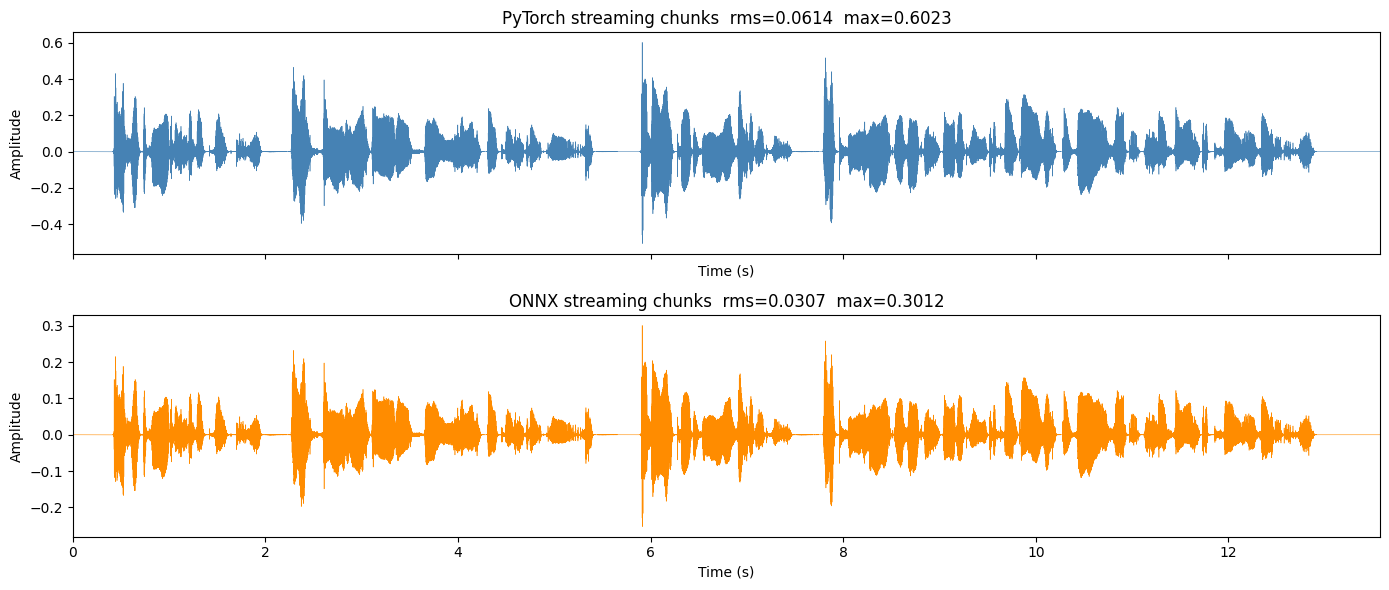

In [13]:
# ═══════════════════════════════════════════════════════════════════════════════
#  ONNX Inference + Comparison
# ═══════════════════════════════════════════════════════════════════════════════

so = ort.SessionOptions()
so.inter_op_num_threads = 4
so.intra_op_num_threads = 4

bert_sess    = ort.InferenceSession(str(onnx_paths["bert"]),           sess_options=so)
dur_sess     = ort.InferenceSession(str(onnx_paths["duration"]),       sess_options=so)
acexp_sess   = ort.InferenceSession(str(onnx_paths["acoustic_expand"]),sess_options=so)
f0n_sess     = ort.InferenceSession(str(onnx_paths["f0n"]),            sess_options=so)
cond_sess    = ort.InferenceSession(str(onnx_paths["conditioner"]),    sess_options=so)
stream_sess  = ort.InferenceSession(str(onnx_paths["stream_chunk"]),   sess_options=so)


def to_numpy(t):
    """Convert tensor to numpy, preserving dtype (no forced float cast for integer tensors)."""
    t = t.detach().cpu()
    if t.is_floating_point():
        t = t.float()
    return t.numpy()


onnx_timings: dict = {}

# ── Stage 1: BERT ──────────────────────────────────────────────────────────────
t0 = _t()
(d_en_np,) = bert_sess.run(None, {
    "input_ids": to_numpy(input_ids),
    "text_mask": to_numpy(text_mask),
})
onnx_timings["bert_encoder"] = (_t() - t0) * 1e3

# ── Stage 2: Duration predictor (static) ──────────────────────────────────────
t0 = _t()
pred_dur_np, d_enc_np, t_en_static_np = dur_sess.run(None, {
    "d_en":       d_en_np,
    "style":      to_numpy(style),
    "text_mask":  to_numpy(text_mask),
    "speed":      to_numpy(speed),
    "input_ids":  to_numpy(input_ids),
})
onnx_timings["duration_predictor"] = (_t() - t0) * 1e3

# ── Stage 3: Duration expansion (Python, not exported) ────────────────────────
t0 = _t()
expanded_indices_onnx, T_acoustic = expand_durations(torch.from_numpy(pred_dur_np))
idx_np = expanded_indices_onnx.numpy()
d_enc_exp_np    = d_enc_np[:, :, idx_np]          # [1, h, T_acoustic]
asr_np          = t_en_static_np[:, :, idx_np]    # [1, 512, T_acoustic]
onnx_timings["duration_expansion_py"] = (_t() - t0) * 1e3

# ── Stage 4: Acoustic expand (shared BiLSTM) ──────────────────────────────────
t0 = _t()
(en_np,) = acexp_sess.run(None, {"d_enc_expanded": d_enc_exp_np})
onnx_timings["acoustic_expand_lstm"] = (_t() - t0) * 1e3

# ── Stage 5: F0/N predictor ────────────────────────────────────────────────────
t0 = _t()
F0_np, N_np = f0n_sess.run(None, {
    "en":    en_np,
    "style": to_numpy(style),
})
onnx_timings["f0n_predictor"] = (_t() - t0) * 1e3

# ── Stage 6: Vocos conditioner (full sequence) ────────────────────────────────
t0 = _t()
features_np = to_numpy(build_vocos_features(
    torch.from_numpy(asr_np), torch.from_numpy(F0_np),
    torch.from_numpy(N_np), style,
))
(conditioned_np,) = cond_sess.run(None, {"features": features_np})
onnx_timings["vocos_conditioner"] = (_t() - t0) * 1e3

# ── Stage 7: Vocos streaming chunks ───────────────────────────────────────────
_sin  = ["embed_prev"] + [f"block_{i}_prev"     for i in range(8)] + ["istft_prev"]
_sout = ["embed_prev_new"] + [f"block_{i}_prev_new" for i in range(8)] + ["istft_prev_new"]

init_state_np = {k: v.numpy() for k, v in VocosStreamChunk.initial_state().items()}
state_np = {new: init_state_np[old] for old, new in zip(
    ["embed_prev"] + [f"block_{i}_prev" for i in range(8)] + ["istft_prev"],
    _sin,
)}

total_frames_onnx = conditioned_np.shape[-1]
onnx_audio_chunks: List[np.ndarray] = []
pos        = 0
n_chunks   = 0
t_chunks   = 0.0
while pos < total_frames_onnx:
    end   = min(total_frames_onnx, pos + VOCOS_CHUNK_FRAMES)
    valid = int(end - pos)
    chunk_np = conditioned_np[..., pos:end]
    if valid < VOCOS_CHUNK_FRAMES:
        chunk_np = np.pad(chunk_np, ((0,0),(0,0),(0, VOCOS_CHUNK_FRAMES - valid)))
    t0 = _t()
    outs = stream_sess.run(None, {"conditioned_chunk": chunk_np, **state_np})
    t_chunks += (_t() - t0) * 1e3
    onnx_audio_chunks.append(outs[0][0, : valid * stream_chunk.hop])
    state_np = dict(zip(_sin, outs[1:]))
    pos = end
    n_chunks += 1

onnx_timings[f"vocos_chunks (×{n_chunks})"] = t_chunks
onnx_audio_np = np.concatenate(onnx_audio_chunks, axis=-1)

# ── Save ───────────────────────────────────────────────────────────────────────
onnx_wav_path = EXPORT_DIR / "onnx_vocos_streaming.wav"
wavfile.write(str(onnx_wav_path), SAMPLE_RATE, (onnx_audio_np * 32767).astype("int16"))
print(f"Saved {onnx_wav_path}")

# ── Compare to PyTorch reference ───────────────────────────────────────────────
pt_np   = audio_vocos.cpu().float().numpy()
min_len = min(len(pt_np), len(onnx_audio_np))
diff    = np.abs(pt_np[:min_len] - onnx_audio_np[:min_len])
print(f"PyTorch output  shape : {pt_np.shape}")
print(f"ONNX output     shape : {onnx_audio_np.shape}")
print(f"Max |PT − ONNX|       : {diff.max():.6f}   (should be ≈0)")

print_timing_table(onnx_timings, title="ONNX Runtime Pipeline Timing")

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
plot_wave(axes[0], torch.from_numpy(pt_np),        "PyTorch streaming chunks", "steelblue")
plot_wave(axes[1], torch.from_numpy(onnx_audio_np),"ONNX streaming chunks",   "darkorange")
plt.tight_layout()
plt.savefig(str(EXPORT_DIR / "waveform_pt_vs_onnx.png"), dpi=100)
plt.show()

display(HTML("<b>PyTorch — streaming chunks:</b>"))
display(Audio(pt_np, rate=SAMPLE_RATE))

display(HTML("<b>ONNX Vocos streaming:</b>"))
display(Audio(onnx_audio_np, rate=SAMPLE_RATE))


In [14]:
# ═══════════════════════════════════════════════════════════════════════════════
#  LiteRT (TFLite) Export via litert_torch
# ═══════════════════════════════════════════════════════════════════════════════
#
#  Modules exported with STATIC shapes (matching ONNX export):
#    bert.tflite               STATIC  [1,510] → [1,512,510]
#    duration_predictor.tflite STATIC  all I/O pinned to MAX_INPUT_LENGTH=510
#    acoustic_expand.tflite    STATIC  T_acoustic=T_ACOUSTIC_MAX=8192
#                              → exported via Keras BiLSTM → TFLiteConverter
#    f0n_predictor.tflite      STATIC  T_acoustic=T_ACOUSTIC_MAX=8192
#    vocoder_conditioner.tflite STATIC  T=T_ACOUSTIC_MAX=8192
#    vocoder_stream_chunk.tflite STATIC  chunk_frames=16, real-arithmetic ISTFT
#
#  ── Speed ─────────────────────────────────────────────────────────────────────
#   • FORCE_LITERT_EXPORT = False: skip existing .tflite files.
#
#  ── InstanceNorm1d with dynamic T ────────────────────────────────────────────
#   Three approaches fail with litert_torch.convert() on dynamic shapes:
#
#      a. nn.InstanceNorm1d: internal view([N*C, T]) — JAX JIT rejects view
#         when T is a dynamic symbolic dim.
#
#      b. F.group_norm: internal view([1, C, 1, T]) — same rejection.
#
#      c. Manual mean/var: works IF T stays on a consistently annotated axis.
#         But F0Ntrain does `F0 = en.transpose(-1,-2)` internally, creating
#         a NEW symbolic dim for T on axis 2 that is NOT connected to the
#         `Dim("T_f0n")` annotation on axis 1 of the input.  Any elementwise
#         op on the [-inf]-shaped tensor then fails.
#
#   By using STATIC shapes (no dynamic_shapes), we bypass this issue entirely.
#   All tensors are sized at T_ACOUSTIC_MAX=8192 at export time.
#
#  ── nn.LSTM (bidirectional) cannot be traced by litert_torch.convert().
#      Solution: Keras Bidirectional(LSTM) + TFLiteConverter.from_keras_model().
#
#  ── Grouped ConvTranspose1d with output_padding ───────────────────────────────
#   litert_torch raises NotImplementedError for output_padding > 0, AND has a
#   MLIR verification bug for grouped ConvTranspose (feature_group_count mismatch:
#   the lowering sets kernel_input_feature_dimension=0 for transposed convs but
#   then StableHLO verifies input_features/groups == kernel.shape[0], which fails
#   when groups == in_channels).
#
#   Fix: _SafeConvTranspose1d replaces grouped ConvTranspose1d by zero-interleaving
#   the input and running a standard forward depthwise conv1d with a flipped kernel.
# ═══════════════════════════════════════════════════════════════════════════════

import copy
import litert_torch
import tensorflow as tf
import numpy as np
from torch.export import Dim
import torch
import torch.nn as nn

# ── SafeInstanceNorm1d — manual norm, no view, no group_norm ─────────────────
class _SafeInstanceNorm1d(nn.Module):
    """InstanceNorm1d via explicit mean/diff formulation (no view, no group_norm).

    Works with static shapes where T is consistently on axis 2.
    Both F.group_norm and aten.var.correction use internal view ops that can
    cause issues with complex tracing backends.
    """
    def __init__(self, src: nn.InstanceNorm1d):
        super().__init__()
        self.eps    = src.eps
        self.affine = src.affine
        if src.affine:
            self.weight = nn.Parameter(src.weight.detach().clone())
            self.bias   = nn.Parameter(src.bias.detach().clone())
        else:
            self.weight = None
            self.bias   = None

    def forward(self, x: Tensor) -> Tensor:
        # x: [N, C, T].  Normalise each (N, C) instance over T (axis 2).
        mean = x.mean(dim=2, keepdim=True)           # [N, C, 1]
        diff = x - mean                              # [N, C, T]
        var  = (diff * diff).mean(dim=2, keepdim=True)  # [N, C, 1]
        x    = diff * (var + self.eps).rsqrt()       # [N, C, T]
        if self.affine:
            x = x * self.weight[None, :, None] + self.bias[None, :, None]
        return x


def _patch_instance_norms(module: nn.Module) -> nn.Module:
    """Recursively replace all InstanceNorm1d with _SafeInstanceNorm1d in-place."""
    for name, child in list(module.named_children()):
        if isinstance(child, nn.InstanceNorm1d):
            setattr(module, name, _SafeInstanceNorm1d(child))
        else:
            _patch_instance_norms(child)
    return module


# ── SafeConvTranspose1d — depthwise ConvTranspose via zero-interleave + conv1d ─
class _SafeConvTranspose1d(nn.Module):
    """ConvTranspose1d with output_padding replaced by explicit post-padding.

    litert_torch raises NotImplementedError for output_padding > 0, AND has a
    MLIR bug for grouped ConvTranspose (feature_group_count mismatch).

    This wrapper implements depthwise ConvTranspose1d by:
      1. Zero-interleaving the input (inserting stride-1 zeros between samples).
      2. Padding to match ConvTranspose output length (including output_padding).
      3. Applying a forward depthwise conv1d with the time-reversed kernel.

    Numerically identical to the original; only handles fully depthwise ops
    (groups == in_channels == out_channels).
    """
    def __init__(self, src: nn.ConvTranspose1d):
        super().__init__()
        assert src.groups == src.in_channels == src.out_channels, (
            "_SafeConvTranspose1d only handles fully depthwise ConvTranspose1d "
            f"(groups==in==out), got groups={src.groups}, in={src.in_channels}, "
            f"out={src.out_channels}"
        )
        self.stride  = src.stride[0]
        self.padding = src.padding[0]
        self.out_pad = src.output_padding[0]
        self.groups  = src.groups
        # Resolve weight_norm hooks (if present) and copy parameters.
        # weight shape: [in_channels, out_channels//groups, kernel] = [C, 1, K]
        self.weight = nn.Parameter(src.weight.detach().clone())
        if src.bias is not None:
            self.bias = nn.Parameter(src.bias.detach().clone())
        else:
            self.bias = None

    def forward(self, x: Tensor) -> Tensor:
        N, C, T = x.shape
        S, P, OP, K = self.stride, self.padding, self.out_pad, self.weight.shape[2]

        # Step 1: zero-interleave — insert (S-1) zeros between each time step.
        xz = torch.stack([x] + [torch.zeros_like(x)] * (S - 1), dim=-1)
        xz = xz.reshape(N, C, T * S)
        xz = xz[:, :, : T * S - (S - 1)]  # [N, C, T*S-(S-1)]

        # Step 2: pad sides to produce the correct ConvTranspose output length.
        side_pad = K - 1 - P
        xz = F.pad(xz, (side_pad, side_pad + OP))

        # Step 3: forward depthwise conv1d with time-reversed kernel (= cross-corr).
        w = self.weight.flip(-1)  # [C, 1, K]
        return F.conv1d(xz, w, self.bias, stride=1, padding=0, groups=self.groups)


def _patch_conv_transpose_output_padding(module: nn.Module) -> nn.Module:
    """Recursively replace ConvTranspose1d layers with output_padding > 0
    with _SafeConvTranspose1d, which is LiteRT-compatible."""
    for name, child in list(module.named_children()):
        if isinstance(child, nn.ConvTranspose1d) and any(p > 0 for p in child.output_padding):
            setattr(module, name, _SafeConvTranspose1d(child))
        else:
            _patch_conv_transpose_output_padding(child)
    return module


# ── F0NPredictorModuleStatic — STATIC shape variant ──────────────────────────
class F0NPredictorModuleStatic(nn.Module):
    """Static-shape variant of F0NPredictorModule for LiteRT export.
    
    Accepts en=[1, T_ACOUSTIC_MAX, 512] and exposes it as [1, 512, T_ACOUSTIC_MAX]
    directly to avoid internal transposes that create symbolic dims.
    With static shapes, all operations trace cleanly.
    """
    def __init__(self, kmodel):
        super().__init__()
        self.F0      = kmodel.predictor.F0
        self.N       = kmodel.predictor.N
        self.F0_proj = kmodel.predictor.F0_proj
        self.N_proj  = kmodel.predictor.N_proj

    def forward(self, en_t: Tensor, style: Tensor):
        # en_t is [1, 512, T_ACOUSTIC_MAX] — C-first layout
        s = style[:, 128:256]
        F0 = en_t
        for block in self.F0:
            F0 = block(F0, s)
        F0 = self.F0_proj(F0)

        N = en_t
        for block in self.N:
            N = block(N, s)
        N = self.N_proj(N)

        return F0.squeeze(1), N.squeeze(1)


# ── Keras BiLSTM wrapper for AcousticExpandModule ────────────────────────────
def _pt_to_keras_bilstm_weights(pt_lstm: nn.LSTM):
    """Convert PyTorch BiLSTM weights to Keras Bidirectional(LSTM) format."""
    def _direction_weights(suffix):
        wih = pt_lstm._parameters[f"weight_ih_l0{suffix}"].detach().numpy()
        whh = pt_lstm._parameters[f"weight_hh_l0{suffix}"].detach().numpy()
        bih = pt_lstm._parameters[f"bias_ih_l0{suffix}"].detach().numpy()
        bhh = pt_lstm._parameters[f"bias_hh_l0{suffix}"].detach().numpy()
        return [wih.T, whh.T, bih + bhh]

    return _direction_weights(""), _direction_weights("_reverse")


def build_acoustic_expand_keras(pt_module: "AcousticExpandModule") -> tf.keras.Model:
    """Build a Keras Bidirectional(LSTM) model matching AcousticExpandModule."""
    pt_lstm = pt_module.shared
    H = pt_lstm.hidden_size
    I = pt_lstm.input_size

    inp = tf.keras.Input(shape=(None, I), batch_size=1, name="d_enc_expanded")
    fwd_lstm = tf.keras.layers.LSTM(H, return_sequences=True, name="fwd")
    bwd_lstm = tf.keras.layers.LSTM(H, return_sequences=True, go_backwards=True, name="bwd")
    out = tf.keras.layers.Bidirectional(fwd_lstm, backward_layer=bwd_lstm,
                                        merge_mode="concat", name="bilstm")(inp)
    model = tf.keras.Model(inputs=inp, outputs=out, name="acoustic_expand")
    fwd_w, bwd_w = _pt_to_keras_bilstm_weights(pt_lstm)
    model.get_layer("bilstm").forward_layer.set_weights(fwd_w)
    model.get_layer("bilstm").backward_layer.set_weights(bwd_w)
    return model


def export_acoustic_expand_tflite(
    pt_module: "AcousticExpandModule",
    pt_sample: Tensor,
    path: Path,
    force: bool = False,
) -> None:
    """Export AcousticExpandModule to TFLite via Keras BiLSTM path."""
    if not force and path.exists():
        sz = path.stat().st_size / 1e6
        print(f"  ↷ {path.name}  (skipped — already exists, {sz:.2f} MB)")
        return

    t0 = _t()
    try:
        keras_model = build_acoustic_expand_keras(pt_module)

        pt_in  = pt_sample.float()
        with torch.no_grad():
            pt_out = pt_module(pt_in)

        keras_in  = pt_in.permute(0, 2, 1).numpy()
        keras_out = keras_model.predict(keras_in, verbose=0)
        max_diff = float(np.abs(pt_out.numpy() - keras_out).max())
        print(f"  acoustic_expand numerics check: max |PT - Keras| = {max_diff:.2e}")
        assert max_diff < 1e-3, f"Numerical mismatch too large: {max_diff}"

        converter = tf.lite.TFLiteConverter.from_keras_model(keras_model)
        tflite_bytes = converter.convert()
        path.write_bytes(tflite_bytes)

        elapsed = (_t() - t0) * 1e3
        sz = path.stat().st_size / 1e6
        print(f"  ✓ {path.name}  {elapsed:.0f} ms  {sz:.2f} MB")
    except Exception as e:
        elapsed = (_t() - t0) * 1e3
        print(f"  ✗ {path.name}  {elapsed:.0f} ms  — {e}")
        import traceback; traceback.print_exc()


# ── Set to True to unconditionally re-export all modules ─────────────────────
FORCE_LITERT_EXPORT: bool = False

litert_paths: Dict[str, Path] = {
    "bert":           EXPORT_DIR / "bert.tflite",
    "duration":       EXPORT_DIR / "duration_predictor.tflite",
    "acoustic_expand":EXPORT_DIR / "acoustic_expand.tflite",
    "f0n":            EXPORT_DIR / "f0n_predictor.tflite",
    "conditioner":    EXPORT_DIR / "vocoder_conditioner.tflite",
    "stream_chunk":   EXPORT_DIR / "vocoder_stream_chunk.tflite",
}

stream_chunk_real = VocosStreamChunkReal(vocos).eval()


def export_litert(
    module,
    sample_args,
    path: Path,
    force: bool = FORCE_LITERT_EXPORT,
):
    """Convert nn.Module to TFLite and save with STATIC shapes.
    
    Skips if file exists and force=False.
    No dynamic_shapes parameter — all I/O fixed at export time.
    """
    if not force and path.exists():
        sz = path.stat().st_size / 1e6
        print(f"  ↷ {path.name}  (skipped — already exists, {sz:.2f} MB)")
        return

    t0 = _t()
    try:
        # No dynamic_shapes → fully static export
        edge_model = litert_torch.convert(module.eval(), sample_args, _ai_edge_converter_flags={
        "verbose": True,
        "detailed_conversion": True,  
        "dynamic_shapes": False,    # STATIC export
        })
        edge_model.export(str(path))
        elapsed = (_t() - t0) * 1e3
        sz = path.stat().st_size / 1e6
        print(f"  ✓ {path.name}  {elapsed:.0f} ms  {sz:.2f} MB")
    except Exception as e:
        elapsed = (_t() - t0) * 1e3
        print(f"  ✗ {path.name}  {elapsed:.0f} ms  — {e}")


# ── 1. BERT encoder  (STATIC) ─────────────────────────────────────────────────
export_litert(bert_module.eval(), sample_args=(input_ids, text_mask),
              path=litert_paths["bert"])

# ── 2. Duration predictor  (STATIC) ───────────────────────────────────────────
export_litert(duration_module.eval(),
              sample_args=(d_en, style, text_mask, speed, input_ids),
              path=litert_paths["duration"])

# ── 3. Acoustic expand  (STATIC T_ACOUSTIC_MAX via Keras BiLSTM) ─────────────
export_acoustic_expand_tflite(acoustic_module.eval(), pt_sample=d_enc_exp,
                              path=litert_paths["acoustic_expand"],
                              force=FORCE_LITERT_EXPORT)

# ── 4. F0/N predictor  (STATIC T_ACOUSTIC_MAX) ───────────────────────────────
#  Build F0NPredictorModuleStatic: takes en=[1, 512, T_ACOUSTIC_MAX] directly.
#  Patch InstanceNorm1d → _SafeInstanceNorm1d (no internal view ops).
#  Patch grouped ConvTranspose1d → _SafeConvTranspose1d (LiteRT MLIR-compatible).
_f0n_static_module = F0NPredictorModuleStatic(kmodel)
_patch_instance_norms(_f0n_static_module)
_patch_conv_transpose_output_padding(_f0n_static_module)

# Verify numerics vs original F0NPredictorModule
_en_t = en.transpose(-1, -2).float()   # [1, 512, T_ACOUSTIC_MAX]
with torch.no_grad():
    _f0n_ref  = f0n_module(en, style)
    _f0n_test = _f0n_static_module(_en_t, style)
_f0n_diff = max((_f0n_ref[0] - _f0n_test[0]).abs().max().item(),
                (_f0n_ref[1] - _f0n_test[1]).abs().max().item())
print(f"  f0n_static numerics check: max |orig - static| = {_f0n_diff:.2e}")
assert _f0n_diff < 1e-4, f"F0N numerics mismatch: {_f0n_diff}"

# Static export: no dynamic_shapes parameter
export_litert(
    _f0n_static_module,
    sample_args=(_en_t, style),
    path=litert_paths["f0n"],
)

# ── 5. Vocos conditioner  (STATIC T_ACOUSTIC_MAX) ─────────────────────────────
export_litert(cond_module.eval(), sample_args=(features.float(),),
              path=litert_paths["conditioner"])

# ── 6. Streaming chunk  (STATIC) ─────────────────────────────────────────────
_init_state_tup = stream_chunk_real.state_as_tuple(VocosStreamChunk.initial_state())
_sample_chunk   = conditioned[..., :VOCOS_CHUNK_FRAMES].float()
export_litert(stream_chunk_real,
              sample_args=(_sample_chunk,) + _init_state_tup,
              path=litert_paths["stream_chunk"])

print("\nLiteRT export complete.")
print("  All modules exported with STATIC shapes (matching ONNX export).")
print("  Tip: set FORCE_LITERT_EXPORT = True to re-export all modules.")


/rhome/eingerman/Projects/DeepLearning/TTS/Kokoro/.venv/lib/python3.12/site-packages/torch/distributed/distributed_c10d.py:351: UserWarning: Device capability of jax unspecified, assuming `cpu` and `cuda`. Please specify it via the `devices` argument of `register_backend`.
  warnings.warn(


  ↷ bert.tflite  (skipped — already exists, 31.89 MB)
  ↷ duration_predictor.tflite  (skipped — already exists, 70.32 MB)
  ↷ acoustic_expand.tflite  (skipped — already exists, 7.37 MB)
  f0n_static numerics check: max |orig - static| = 0.00e+00
  ↷ f0n_predictor.tflite  (skipped — already exists, 27.50 MB)
  ↷ vocoder_conditioner.tflite  (skipped — already exists, 1.09 MB)
  ↷ vocoder_stream_chunk.tflite  (skipped — already exists, 43.98 MB)

LiteRT export complete.
  All modules exported with STATIC shapes (matching ONNX export).
  Tip: set FORCE_LITERT_EXPORT = True to re-export all modules.


In [26]:
# ═══════════════════════════════════════════════════════════════════════════════
#  LiteRT (TFLite) Inference — static-shape bypass
# ═══════════════════════════════════════════════════════════════════════════════
#
#  Background: litert_torch.TfLiteModel.__call__ always calls
#  SignatureRunner.__call__ → ResizeInputTensor + AllocateTensors.
#  For models exported with XNNPack at static shapes, ResizeInputTensor triggers
#  a "prepare" step that fails even when the shape is unchanged.
#
#  Context: XNNPack has a limited thread-pool and cannot host many concurrent
#  interpreters. litert_torch avoids this by creating a fresh interpreter on
#  every __call__ (and letting GC reclaim it immediately after), never holding
#  multiple alive at once. We replicate that pattern and additionally skip
#  ResizeInputTensor by using _interpreter_wrapper directly.
#
#  • litert_torch models (bert, duration, f0n, conditioner, stream_chunk):
#    _LiteRTStaticRunner — reads model_content at init, creates a fresh
#    interpreter per __call__ (no persistent interpreter), skips ResizeInputTensor,
#    pads inputs to the compiled static shape.
#  • acoustic_expand.tflite (Keras BiLSTM export):
#    _TFLiteKeras — uses tf.lite.Interpreter (compatible with Keras export),
#    same pad-then-invoke approach.
#  All models were exported at static T_ACOUSTIC_MAX = 8192.

import re
import numpy as np
import tensorflow as tf
from ai_edge_litert import interpreter as litert_interpreter

def to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.cpu().detach().numpy()
    return np.asarray(x)

def pad_to(arr: np.ndarray, target_len: int, axis: int) -> np.ndarray:
    if arr.shape[axis] >= target_len:
        return arr
    pw = [(0, 0)] * arr.ndim
    pw[axis] = (0, target_len - arr.shape[axis])
    return np.pad(arr, pw)

def crop_to(arr: np.ndarray, length: int, axis: int) -> np.ndarray:
    sl = [slice(None)] * arr.ndim
    sl[axis] = slice(0, length)
    return arr[tuple(sl)]

def _num_sort(name: str):
    m = re.search(r'\d+', name)
    return int(m.group()) if m else name


class _LiteRTStaticRunner:
    """Bypass ResizeInputTensor for static-shape ai_edge_litert models.

    Creates a fresh interpreter on each __call__ (matching litert_torch's own
    pattern), so XNNPack resources are released immediately after inference.
    Uses _interpreter_wrapper.SetTensor / Invoke / GetTensor directly to skip
    the ResizeInputTensor that SignatureRunner.__call__ would otherwise issue.
    Inputs are zero-padded to the compiled static shape automatically.
    """
    def __init__(self, path: str):
        with open(path, 'rb') as f:
            self._model_content = f.read()
        # Validate: check signature list without allocate_tensors
        tmp = litert_interpreter.Interpreter(model_content=self._model_content)
        tmp.get_signature_list()   # raises if model is invalid
        del tmp

    def __call__(self, *args) -> list:
        # Fresh interpreter each call — no persistent XNNPack context
        interp = litert_interpreter.Interpreter(
            model_content=self._model_content,
            experimental_default_delegate_latest_features=True,
        )
        interp.allocate_tensors()
        runner  = interp.get_signature_runner()
        wrapper = runner._interpreter_wrapper
        sg      = runner._subgraph_index
        in_map  = runner._inputs                              # name → tensor_idx
        out_map = {k: v for k, v in runner._outputs}         # name → tensor_idx
        in_names  = sorted(in_map.keys(),  key=_num_sort)
        out_names = sorted(out_map.keys(), key=_num_sort)

        for name, raw in zip(in_names, args):
            idx    = in_map[name]
            static = wrapper.GetTensor(idx, sg)
            arr    = np.asarray(raw).astype(static.dtype)
            if arr.shape != static.shape:
                padded = np.zeros(static.shape, dtype=static.dtype)
                sl     = tuple(slice(0, min(arr.shape[j], static.shape[j]))
                               for j in range(arr.ndim))
                padded[sl] = arr[sl]
                arr = padded
            wrapper.SetTensor(idx, arr, sg)

        wrapper.Invoke(sg)
        return [wrapper.GetTensor(out_map[n], sg).copy() for n in out_names]


class _TFLiteKeras:
    """tf.lite.Interpreter wrapper for Keras-exported static TFLite models.

    Pads each input to the compiled shape, runs without resize.
    The interpreter is allocated once at init (Keras TFLite is compatible
    with the persistent-interpreter pattern).
    """
    def __init__(self, path: str):
        self._interp = tf.lite.Interpreter(model_path=path)
        self._interp.allocate_tensors()
        self._in_det  = self._interp.get_input_details()
        self._out_det = self._interp.get_output_details()

    def __call__(self, *args) -> list:
        for det, raw in zip(self._in_det, args):
            arr = np.asarray(raw, dtype=det["dtype"])
            exp = det["shape"]
            if arr.shape != tuple(exp):
                padded = np.zeros(exp, dtype=det["dtype"])
                sl = tuple(slice(0, min(arr.shape[j], exp[j])) for j in range(arr.ndim))
                padded[sl] = arr[sl]
                arr = padded
            self._interp.set_tensor(det["index"], arr)
        self._interp.invoke()
        return [self._interp.get_tensor(d["index"]).copy() for d in self._out_det]


# ── Load models ───────────────────────────────────────────────────────────────
print("Loading LiteRT models...")
lt_bert         = _LiteRTStaticRunner(str(litert_paths["bert"]))
lt_duration     = _LiteRTStaticRunner(str(litert_paths["duration"]))
lt_acoustic_exp = _TFLiteKeras(str(litert_paths["acoustic_expand"]))  # Keras BiLSTM
lt_f0n          = _LiteRTStaticRunner(str(litert_paths["f0n"]))
lt_conditioner  = _LiteRTStaticRunner(str(litert_paths["conditioner"]))
lt_stream_chunk = _LiteRTStaticRunner(str(litert_paths["stream_chunk"]))
print("✓ All LiteRT models loaded.\n")

# ── Pipeline ──────────────────────────────────────────────────────────────────
timings_litert: Dict[str, float] = {}

try:
    # Stage 1: BERT encoder — [1, MAX_INPUT_LENGTH] → [1, 512, MAX_INPUT_LENGTH]
    t = _t()
    lt_enc_out = lt_bert(to_numpy(input_ids), to_numpy(text_mask))
    d_en_lt = lt_enc_out[0].astype(np.float32)
    timings_litert["BERT"] = (_t() - t) * 1e3

    # Stage 2: Duration predictor — returns (pred_dur, d_enc, t_en_static)
    t = _t()
    lt_dur_out = lt_duration(
        d_en_lt,
        to_numpy(style),
        to_numpy(text_mask),
        to_numpy(speed),
        to_numpy(input_ids),
    )
    pred_dur_lt = lt_dur_out[0].astype(np.float32)
    timings_litert["DurationPredictorCore"] = (_t() - t) * 1e3

    # Stage 3: Expand durations
    # expand_durations returns (expanded_indices: Tensor, T_acoustic: int)
    t = _t()
    expanded_indices_lt, _ = expand_durations(torch.from_numpy(pred_dur_lt))
    idx_lt      = expanded_indices_lt.numpy()
    d_en_exp_lt = d_en_lt[:, :, idx_lt]                      # [1, 512, T_actual]
    T_actual_lt = d_en_exp_lt.shape[2]
    timings_litert["expand_durations"] = (_t() - t) * 1e3

    # Stage 4: Acoustic expand (Keras BiLSTM)
    # I/O is C-last [1, T, h] → [1, T, 512]. Pad T to T_ACOUSTIC_MAX, run, crop + transpose.
    t = _t()
    ac_in    = pad_to(d_en_exp_lt.transpose(0, 2, 1), T_ACOUSTIC_MAX, axis=1)
    lt_ac_out = lt_acoustic_exp(ac_in)                        # [1, T_MAX, 512]
    ac_exp_lt = crop_to(lt_ac_out[0], T_actual_lt, axis=1).transpose(0, 2, 1).astype(np.float32)
    timings_litert["AcousticExpandModule"] = (_t() - t) * 1e3

    # Stage 5: F0/N predictor
    # F0NPredictorModuleStatic: en_t = [1, 512, T_ACOUSTIC_MAX] (C-first).
    t = _t()
    lt_f0n_out = lt_f0n(
        pad_to(ac_exp_lt, T_ACOUSTIC_MAX, axis=2),
        to_numpy(style),
    )
    F0_lt = torch.from_numpy(crop_to(lt_f0n_out[0], T_actual_lt, axis=1)).float()
    N_lt  = torch.from_numpy(crop_to(lt_f0n_out[1], T_actual_lt, axis=1)).float()
    timings_litert["F0NPredictorModule"] = (_t() - t) * 1e3

    # Stage 6: Vocos conditioner — [1, 642, T_ACOUSTIC_MAX] → [1, ?, T_ACOUSTIC_MAX]
    asr_lt      = torch.from_numpy(ac_exp_lt).float()
    features_lt = build_vocos_features(asr_lt, F0_lt, N_lt, style)  # [1, 642, T_actual]

    t = _t()
    lt_cond_out = lt_conditioner(
        pad_to(to_numpy(features_lt.float()), T_ACOUSTIC_MAX, axis=2),
    )
    conditioned_lt = crop_to(lt_cond_out[0], T_actual_lt, axis=2).astype(np.float32)
    timings_litert["VocosConditioner"] = (_t() - t) * 1e3

    # Stage 7: Streaming chunks
    # Determine initial state shapes from one trial run
    _dummy_chunk    = np.zeros((1, lt_f0n_out[0].shape[1], VOCOS_CHUNK_FRAMES), dtype=np.float32)
    _dummy_interp   = litert_interpreter.Interpreter(
        model_content=lt_stream_chunk._model_content,
        experimental_default_delegate_latest_features=True,
    )
    _dummy_interp.allocate_tensors()
    _dummy_runner   = _dummy_interp.get_signature_runner()
    _in_names_sc    = sorted(_dummy_runner._inputs.keys(),  key=_num_sort)
    _state_in_names = _in_names_sc[1:]  # all except the first (conditioned chunk)
    _state_shapes   = [
        _dummy_runner._interpreter_wrapper.GetTensor(
            _dummy_runner._inputs[n], _dummy_runner._subgraph_index
        ).shape
        for n in _state_in_names
    ]
    del _dummy_interp, _dummy_runner
    state_np_lt = [np.zeros(s, dtype=np.float32) for s in _state_shapes]

    t = _t()
    chunk_times  = []
    audio_chunks = []

    for i in range(0, conditioned_lt.shape[-1], VOCOS_CHUNK_FRAMES):
        t_chunk = _t()
        chunk = conditioned_lt[..., i : i + VOCOS_CHUNK_FRAMES]
        if chunk.shape[-1] < VOCOS_CHUNK_FRAMES:
            chunk = pad_to(chunk, VOCOS_CHUNK_FRAMES, axis=-1)

        lt_chunk_out = lt_stream_chunk(chunk, *state_np_lt)

        chunk_audio  = lt_chunk_out[0][0].astype(np.float32)
        state_np_lt  = [o.astype(np.float32) for o in lt_chunk_out[1:]]

        audio_chunks.append(chunk_audio)
        chunk_times.append((_t() - t_chunk) * 1e3)

    audio_lt = np.concatenate(audio_chunks, axis=-1)
    timings_litert["VocosStreamChunks"] = (_t() - t) * 1e3

    # ── Numerical comparison ─────────────────────────────────────────────────
    print("LiteRT vs PyTorch comparison:")
    d_en_np = to_numpy(d_en)
    print(f"  d_en_lt max diff:        {np.abs(d_en_np - d_en_lt[:, :, :d_en_np.shape[2]]).max():.2e}")
    p_np    = to_numpy(pred_dur)
    print(f"  pred_dur_lt max diff:    {np.abs(p_np - pred_dur_lt[:, :p_np.shape[-1]]).max():.2e}")
    en_np   = to_numpy(en.permute(0, 2, 1))   # [1, 512, T_actual]
    print(f"  ac_exp_lt max diff:      {np.abs(en_np - ac_exp_lt).max():.2e}")
    cond_np = to_numpy(conditioned)
    print(f"  conditioned_lt max diff: {np.abs(cond_np - conditioned_lt).max():.2e}")
    aud_np  = to_numpy(audio_pt)
    print(f"  audio_lt max diff:       {np.abs(aud_np - audio_lt[:len(aud_np)]).max():.2e}")
    print()

    print_timing_table(timings_litert, "LiteRT Pipeline")

except Exception as e:
    print(f"LiteRT inference failed: {e}")
    import traceback
    traceback.print_exc()


Loading LiteRT models...
✓ All LiteRT models loaded.

LiteRT inference failed: XNNPack delegate failed to reshape runtimeNode number 20 (TfLiteXNNPackDelegate) failed to prepare.


Traceback (most recent call last):
  File "/tmp/ipykernel_2756636/10576518.py", line 192, in <module>
    lt_cond_out = lt_conditioner(
                  ^^^^^^^^^^^^^^^
  File "/tmp/ipykernel_2756636/10576518.py", line 75, in __call__
    interp.allocate_tensors()
  File "/rhome/eingerman/Projects/DeepLearning/TTS/Kokoro/.venv/lib/python3.12/site-packages/ai_edge_litert/interpreter.py", line 554, in allocate_tensors
    return self._interpreter.AllocateTensors()
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: XNNPack delegate failed to reshape runtimeNode number 20 (TfLiteXNNPackDelegate) failed to prepare.
